# Joint allocation search at 150,000

Based on `64-opt-sharpe-partial-day-cadence-10bps.ipynb` for the optimiser harness, and on
`72-backtest-inverse-variance-33pct-concentration.ipynb` for the `inverse_variance` sizing rule.

**The first optimiser run in this chain at anything other than a 25,000 bankroll.** All sixteen
previous optimiser notebooks - NB09 through NB64 - use `initial_cash = 25_000`, and every 150,000
result so far (NB67, NB68, NB70, NB72) comes from a hand-built grid varying one or two parameters
while the rest sat at their 25,000-derived values.

## Searched

| Parameter | Values | Why it is in the search |
|---|---|---|
| `max_concentration_pct` | 0.25, 0.33, 0.40, 0.50 | **Reverses with capital.** 33% > 50% at 25,000 (NB65); 50% > 33% at 150,000 (NB68) |
| `per_position_cap_of_pool_pct` | 0.15, 0.20, 0.25, 0.30 | Best-evidenced lever in the chain: +4.61 pp at 75,000, **+20.34 pp** at 150,000 (NB67) |
| `max_assets_in_portfolio` | 5, 6, 7, 8 | Non-monotone: 6 best on CAGR, 8 best on Sharpe, a reproducible hole at 7 (NB68) |
| `inverse_vol_window` | 30, 45, 60, 90 | Last searched on 41%-forward-filled data (NB28/NB29); interacts with everything else |
| `sell_rebalance_min_threshold_usd` | $5, $375, $750, $1,500 | 0.25% / 0.5% / 1.0% of capital, stopping below the crash boundary |

## Pinned

- **150,000 capital**, **native 2-day cadence** (`cycle_duration = cycle_2d`), **10 BPS** exit fee
- **`inverse_variance` sizing** - NB72 measured +2.77 pp of CAGR against `inverse_vol`, winning at
  7 of 7 lookbacks on both windows with an interior optimum at k=2
- `minimum_hold_days = 1` - retired from the search after NB63, NB64, NB69 and NB70 all found it
  inert or harmful

## Why a joint search, and what to watch

Four documented interactions make one-at-a-time tuning unsafe here. Concentration reverses with
capital; the pool cap's value triples between 75,000 and 150,000; breadth trades CAGR against
Sharpe; and the sizing exponent wins at a 25% pool cap while losing at 20% (NB69 against NB72) - a
contradiction no single-axis experiment has explained.

The objective is **Sharpe**, following NB64: Calmar divides one rounded quantity by another small
one, so a single rounding step moved it by 0.81 against a true spread of 0.062. Note this deliberately
will *not* reward `inverse_variance` for the thing it is best at - NB72 found its gain is
return-only, with Sharpe moving +0.02 - so the pinned sizing rule is being judged by a metric
indifferent to it.

Two known traps are handled explicitly:

- **`ignore_wallet_errors=True` scores crashes as zeros**, which ranks an unrunnable configuration
  last instead of reporting it. That is how the `$250` softband won NB63 and NB64. Crashes are
  listed and their common parameter identified.
- **The grid search cache key covers only the searched parameters**, so the capital change from
  25,000 requires a cleared cache or it will serve NB64's results.

## Key new insights and what did we learn from this experiment?

> **This notebook was re-run after trade-executor
> [#1621](https://github.com/tradingstrategy-ai/trade-executor/pull/1621).** Its first run was
> largely destroyed by a Hypercore dust-close defect - a USD threshold compared against a share
> count - which silently deleted funded positions. The grid search cache was cleared and all 108
> evaluations recomputed. The sections below are the post-fix results; the defect and how it was
> found are recorded at the end.

### The joint optimum, and it now agrees with the single-axis notebooks

| Lookback | Vaults | Concentration | Pool cap | Softband | CAGR | Max DD | Sharpe | Calmar |
|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| **45** | **6** | **0.50** | **0.25** | $1,500 | **48.92%** | -4.63% | **2.76** | 10.56 |
| 45 | 6 | 0.50 | 0.25 | $5 | 48.28% | -4.62% | 2.74 | 10.45 |
| 45 | 6 | 0.50 | 0.25 | $750 | 48.29% | -4.60% | 2.73 | 10.49 |
| 45 | 6 | 0.50 | 0.30 | $1,500 | 46.88% | **-3.65%** | 2.70 | **12.83** |
| 45 | 6 | 0.50 | 0.30 | $375 | 46.10% | -3.54% | 2.68 | **13.01** |
| 60 | 6 | 0.50 | 0.30 | $1,500 | 48.56% | -4.87% | 2.69 | 9.97 |

Every one of the top six uses **6 vaults at 50% concentration**, and five of six use a **45-day
lookback**. That is the first time the joint search has agreed with the notebooks that searched
those axes one at a time:

- **6 vaults** - NB68 found 6 best on CAGR at 150,000
- **50% concentration** - NB68 found 50% beats 33% at this bankroll, reversing the 25,000 result
- **45-day lookback** - NB70 found a 45-60 day plateau, with 45 preferred on clean daily data
- **25-30% pool cap** - NB67 measured the cap as the dominant lever, worth +20.34 pp at 150,000

Before the fix this notebook disagreed with all four, preferring 5 vaults at 0.40 concentration.
That disagreement was an artefact.

**The softband remains irrelevant**, for the fifth notebook running: the same allocation appears at
$1,500, $750, $375 and $5 within 0.65 pp of CAGR. Pick it for trade-count hygiene, not return.

**Pool cap 0.25 versus 0.30 is an objective choice**: 0.25 wins on CAGR and Sharpe (48.92%, 2.76),
0.30 wins on drawdown and Calmar (-3.54%, 13.01). Both dominate 0.15 and 0.20.

### What the fix was worth

| | Pre-fix | Post-fix |
|---|---:|---:|
| Crashed | 33 | **11** |
| Failed the accounting check | 41 | **15** |
| **Sound** | **34 (31%)** | **82 (76%)** |
| Best Sharpe | 1.394 | **2.757** |
| Best CAGR | 31.84% | **48.92%** |
| Best Calmar | 2.59 | **13.01** |

Two thirds of the search budget was previously wasted. The usable fraction went from under a third
to three quarters, and the best configuration found improved by 17 pp of CAGR and 1.36 of Sharpe -
because the region the corrupted runs occupied is exactly where the optimum lives.

**Crashes fell from 33 to 11 as a side effect.** All 11 remaining are at the $1,500 softband, which
is the separate buy-budget defect NB74 diagnosed and fixed with `cap_buys_to_sync_cash`; this
notebook does not enable it. The other 22 were downstream of destroyed positions: deleting a
funded holding distorts the cash plan on later cycles until the wallet runs short.

### A residual accounting gap remains, and it is small

15 configurations still fail the identity, but the magnitude has collapsed: **1.22% to ~2.0% of
capital**, against a pre-fix median of 12.59% and a worst case of 94.59%. They cluster on wide
baskets - 67% at 7 vaults, 53% at 0.50 concentration - which is consistent with a small-position
effect the dust fix did not fully close.

At this size the residual is close to the 1% tolerance itself, so some of these may be threshold
artefacts rather than a second defect. It is worth one more look before trusting 7-8 vault results
at this bankroll, but it does not affect the optimum found here, which sits at 6 vaults.

## Summary of results

**Best configuration: 45-day lookback, 6 vaults, 50% concentration, 25% pool cap** -
48.92% CAGR, -4.63% drawdown, Sharpe 2.76, Calmar 10.56, at a 150,000 bankroll with
`inverse_variance` sizing, a native 2-day cadence and a 10 BPS exit fee.

For the best risk-adjusted variant, the same allocation at a **30% pool cap** gives 46.10% CAGR at
**-3.54% drawdown and Calmar 13.01** - 2.8 pp less return for 1.1 pp less drawdown.

| Metric | Best (0.25 cap) | Best Calmar (0.30 cap) |
|---|---:|---:|
| CAGR | **48.92%** | 46.10% |
| Max drawdown | -4.63% | **-3.54%** |
| Sharpe | **2.76** | 2.68 |
| Calmar | 10.56 | **13.01** |
| Trades | 369 | 426 |

## Robustness of results

- **The 108 evaluations were fully recomputed**: the grid search cache key covers only searched
  parameters, so it would have served the pre-fix results back unchanged. Clearing
  `~/.cache/tradingstrategy/grid-search/73-opt-150k-allocation-joint-search/` was mandatory, not
  hygiene.
- **The accounting identity is applied as a filter, and it still excludes 15 runs.** Treat the
  table as the sound subset, not as the whole search.
- **The Gaussian Process still explored using some corrupted objective values.** 26 of 108
  evaluations were unusable, and the GP chose where to sample next partly on the basis of those
  scores. Coverage is therefore worse than 82 of 1,024 cells suggests. The proper fix is to pass
  the integrity check as `result_filter` so the optimiser never sees an incoherent score.
- **The optimum sits at the edge on one axis.** Concentration 0.50 is the highest value searched
  and it dominates the top of the table, so the true optimum may lie beyond it. The pool cap, by
  contrast, has an interior optimum at 0.25-0.30.
- **`inverse_variance` sizing is pinned, not searched**, and NB72 measured its advantage over
  `inverse_vol` as return-only (+2.77 pp CAGR, +0.02 Sharpe). The objective here is Sharpe, which
  is indifferent to that advantage.
- One window, 2026-01-01 to 2026-07-10, of which the first fortnight is 55% covered. Same caveat as
  the rest of the chain.

## The defect this notebook exposed

The first run of this notebook produced a 42.05% CAGR "winner" that was built on broken books, and
41 of 75 completed evaluations failed an accounting check. Investigating that led to NB74 and to
trade-executor #1621.

`get_hyperliquid_vault_close_epsilon()` returned `initial_cash * 0.005` - a **US dollar** amount -
and `TradingPosition.can_be_closed()` compared it against `get_quantity()`, a count of **vault
shares**. At a 150,000 bankroll the dust threshold became 750 *shares*; for a vault priced at
12.78 USD that is 9,585 USD, so freshly opened positions were book-closed as "dust" on the
timestamp they were opened. `close_position()` sells nothing, so the holdings vanished with no
offsetting cash and no realised loss.

The accounting identity `final equity == initial + realised + unrealised - fees` is what surfaced
it, after several notebooks had accepted the corrupted equity curves as strategy results. It is
now a standard cell here and in NB67.

Notably, **not every 150,000 notebook was affected**: NB67, NB68 and NB72 reproduce their pre-fix
numbers exactly and their conclusions stand unchanged. The damage required configurations that hold
positions small enough to fall under the share threshold, which this search space contains and
their fixed configurations did not.


## Notebook setup

- Shared imports, chart output settings, and notebook logging for the clean-up variant.

In [1]:
import datetime
import logging

import pandas as pd
import plotly.express as px
from IPython.display import display

from tradingstrategy.client import Client
from tradeexecutor.utils.notebook import setup_charting_and_output, OutputMode

client = Client.create_jupyter_client()
setup_charting_and_output(OutputMode.static, image_format='png', width=1500, height=1000)
logger = logging.getLogger('strategy')

Started Trading Strategy in Jupyter notebook environment, configuration is stored in /Users/moo/.tradingstrategy


## Universe definition

- Use the same Hyperliquid survivor-first vault universe as NB152 so the clean-up stays directly comparable.

In [2]:
from eth_defi.token import USDC_NATIVE_TOKEN
from tradingstrategy.chain import ChainId
from tradeexecutor.state.identifier import AssetIdentifier

CHAIN_ID = ChainId.hyperliquid

EXCHANGES = ('uniswap-v2', 'uniswap-v3')
SUPPORTING_PAIRS = [
    (ChainId.arbitrum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WBTC', 'USDC', 0.003),
]
LENDING_RESERVES = None
PREFERRED_STABLECOIN = AssetIdentifier(
    chain_id=ChainId.hyperliquid.value,
    address=USDC_NATIVE_TOKEN[ChainId.hyperliquid].lower(),
    token_symbol='USDC',
    decimals=6,
)
ALLOWED_VAULT_DENOMINATION_TOKENS = {'USDC', 'USDT', 'USDC.e', 'crvUSD', 'USDT0', 'USD₮0', 'USDt', 'USDS'}

print(f'Chain universe: {CHAIN_ID.get_name()}')
print(f'Reserve asset: {PREFERRED_STABLECOIN}')


Chain universe: HyperEVM
Reserve asset: <USDC at 0xb88339cb7199b77e23db6e890353e22632ba630f>


## Parameters

- **Pinned**: `max_concentration_pct = 0.35`, `max_assets_in_portfolio = 6`, 10 BPS exit fee.
- The engine steps every 12 hours, so `rebalance_every_n_cycles` counts **12-hour cycles**:
  1 = 12h, 2 = 24h, 3 = 36h, 4 = 48h, 5 = 60h, 6 = 72h.
- **Searched**: `rebalance_every_n_cycles` (1-6), `minimum_hold_days` (1-4) and
  `sell_rebalance_min_threshold_usd` (5 / 50 / 125 / 250 USD).
- Hold values above 4 days and the 25 USD softband were dropped: NB63 measured both as
  monotonically worse or indistinguishable, and the space is better spent on cadence resolution.


In [3]:
from tradeexecutor.strategy.cycle import CycleDuration
from tradeexecutor.strategy.default_routing_options import TradeRouting
from tradeexecutor.strategy.parameters import StrategyParameters
from skopt.space import Categorical

from tradingstrategy.timebucket import TimeBucket


class Parameters:
    #: Notebook identifier.
    id = '73-opt-150k-allocation-joint-search'

    #: Daily candles match the whole Hyperliquid survivor-first research chain.
    candle_time_bucket = TimeBucket.d1
    #: Native 2-day rebalance cadence. NB63, NB64 and NB65 all settled on 48 hours, and NB65
    #: verified a native `cycle_2d` reproduces NB64's modulo-counter version to within 0.36 pp, so
    #: the cadence is pinned here rather than searched and the modulo counter is retired.
    #:
    #: Relies on the trade-executor fix that makes `perform_optimisation()` forward
    #: `cycle_duration`; without it the optimiser silently reverts to a daily clock.
    cycle_duration = CycleDuration.cycle_2d
    #: HyperEVM is the primary chain for vaults.
    chain_id = CHAIN_ID
    #: HyperEVM is the primary execution chain.
    primary_chain_id = CHAIN_ID
    #: Same exchange set as the release-candidate notebooks.
    exchanges = EXCHANGES

    #: **Searched.** NB68 found 6 best on CAGR and 8 best on Sharpe/Calmar/drawdown at 150,000,
    #: with a reproducible hole at 7 - so the axis is not monotone and the optimum depends on the
    #: objective. Searched jointly here rather than settled by eye.
    max_assets_in_portfolio = Categorical([5, 6, 7, 8])
    #: 98% target deployment, the validated release default.
    allocation_pct = 0.98
    #: **Searched.** The one parameter known to reverse with capital: NB65 measured 33% > 50% at
    #: 25,000, NB68 measured 50% > 33% at 150,000. At large size the ceiling stops being risk
    #: control and becomes a deployment constraint.
    max_concentration_pct = Categorical([0.25, 0.33, 0.40, 0.50])
    #: **Searched.** The best-evidenced lever in the chain: NB67 measured 15% -> 25% as worth
    #: +4.61 pp at 75,000 and +20.34 pp at 150,000, and NB68 confirmed a gain in all six
    #: combinations tested. 0.30 extends past anything measured so far.
    per_position_cap_of_pool_pct = Categorical([0.15, 0.20, 0.25, 0.30])
    #: Engine hygiene threshold for cleaning up tiny residual positions.
    min_portfolio_weight_pct = 0.005

    #: Retired: the cadence is now the engine's own 2-day cycle, so every cycle acts.
    rebalance_every_n_cycles = 1
    #: Retired from the search: NB63 and NB64 both found it inert at or below the cadence and
    #: harmful above it, and NB69/NB70 confirmed no configuration wanted it.
    minimum_hold_days = 1

    #: Hyperliquid has a hard 5 USD minimum deposit.
    absolute_min_vault_deposit_usd = 5.0
    #: Buy threshold as a fraction of initial cash. Deposits are free under an exit-only
    #: fee, so the buy side stays tight and is not searched.
    individual_rebalance_min_threshold_of_initial_cash_pct = 0.0005
    #: **Searched.** Sell-side softband in USD at a 150,000 bankroll: the $5 hard floor plus
    #: 0.25%, 0.5% and 1.0% of capital.
    #:
    #: The ladder stops at 1%. NB66 established the crash boundary is a fraction of capital -
    #: between 1% and 2% at every bankroll tested - because suppressed sells are not deducted from
    #: the buy budget, so a wide band lets the plan spend proceeds from a trim it then cancels.
    #: NB67 confirmed $3,000 (2%) and $6,000 (4%) both fail at 150,000 while $1,500 (1%) survives.
    #: 1% is the edge rather than a safe margin, so any crash at that rung is surfaced below
    #: instead of being scored as a zero.
    sell_rebalance_min_threshold_usd = Categorical([5.0, 375.0, 750.0, 1500.0])

    #: Survivor-first TVL floor selected in NB141.
    min_tvl_usd = 7_500

    #: Trailing window (days) for the CAGR leg of the composite selection score.
    cagr_lookback_days = 360
    #: Trailing window (days) for the Sharpe leg of the composite selection score.
    sharpe_lookback_days = 180
    #: Composite blend: ``cagr_weight x CAGR score + (1 - cagr_weight) x Sharpe score``.
    #: NB31 showed both legs are load-bearing: either leg alone is materially worse on
    #: both CAGR and drawdown.
    cagr_weight = 0.50
    #: Momentum gate window: a vault is eligible only while its trailing return over
    #: this window exceeds :py:attr:`gate_threshold`. NB31: pure drawdown insurance at
    #: zero return cost (removal: -4.5pp CAGR and max DD -7.4% -> -17.5%).
    gate_lookback_days = 14
    #: Momentum gate threshold (fraction).
    gate_threshold = -0.08
    #: **Searched.** The window for the volatility estimate that becomes the sizing weight.
    #:
    #: NB70 found a broad 45-60 day plateau with sharp falloff either side and no reason to move
    #: off 60 on its own - but it also found the exponent and the window are separate levers, and
    #: the window was last searched (NB28/NB29) on data that was 41% forward-filled. It is in the
    #: search because it interacts with everything else here, not because 60 looked wrong.
    #:
    #: This is an **indicator** parameter. `prepare_grid_combinations()` calls
    #: `create_indicators()` with each combination's own parameters, so every value gets its own
    #: indicator series - unlike a hand-built grid, where reusing a precomputed indicator set
    #: would silently give every cell the same 60-day series.
    inverse_vol_window = Categorical([30, 45, 60, 90])

    #: Pinned: size by 1/sigma^2 rather than 1/sigma. NB72 measured +2.77 pp of CAGR at 60 days,
    #: winning at 7 of 7 lookbacks on both the full window and clean daily data, with a genuine
    #: interior optimum at k=2. Note the gain is return-only - Sharpe moved +0.02 and drawdown
    #: 0.57 pp worse - so this pins the return-maximising choice, and the search below optimises
    #: Sharpe, which will not reward it for that.
    weighting_method = 'inverse_variance'

    #: Unused while :py:attr:`weighting_method` is ``inverse_variance``; kept so the sizing helper
    #: has a value for every branch.
    weighting_exponent = 2.0
    softmax_temperature = 0.25

    #: Start trading from January 2026 while retaining pre-start indicator history.
    backtest_start = datetime.datetime(2026, 1, 1)
    #: Exclusive end boundary.
    backtest_end = datetime.datetime(2026, 7, 10)
    #: Release-candidate bankroll.
    initial_cash = 150_000
    #: Derived at class creation time from the configured initial cash and the 5 USD hard floor.
    individual_rebalance_min_threshold_usd = max(
        absolute_min_vault_deposit_usd,
        initial_cash * individual_rebalance_min_threshold_of_initial_cash_pct,
    )

    #: Optimiser runs do not model managed yield.
    use_managed_yield = False

    #: Default routing is still required by the strategy runtime even though it is not the alpha source.
    routing = TradeRouting.default
    #: Set deliberately high so live and notebook indicator calculations use effectively
    #: all available history; history-derived indicators would be silently biased by a
    #: truncated lookback window.
    required_history_period = datetime.timedelta(days=365 * 20)
    #: Same live-style slippage assumption as the release-candidate notebooks.
    slippage_tolerance_pct = 0.0060
    #: Vault exit fee charged on every Hypercore redemption. Applied to the trading
    #: universe as a sell-side token tax, see the universe cell.
    vault_redemption_fee = 0.0010
    #: Assume no liquidity if there is a gap in TVL data.
    assummed_liquidity_when_data_missings_usd = 0.01


parameters = StrategyParameters.from_class(Parameters)

from tradeexecutor.strategy.parameters import display_parameters

display_parameters(parameters)


,Value,Type
Name,,
absolute_min_vault_deposit_usd,5.0,float
allocation_pct,0.98,float
assummed_liquidity_when_data_missings_usd,0.01,float
backtest_end,2026-07-10 00:00:00,datetime
backtest_start,2026-01-01 00:00:00,datetime
cagr_lookback_days,360,int
cagr_weight,0.5,float
candle_time_bucket,TimeBucket.d1,TimeBucket
chain_id,999,ChainId


## Trading universe

- Build the tradable supporting-pair and Hyperliquid vault universe used by the backtest.

In [4]:
from pathlib import Path
import shutil
import time

from dotenv import load_dotenv
from tradingstrategy.utils.token_filter import filter_for_selected_pairs
from tradeexecutor.analysis.pair import display_strategy_universe
from tradeexecutor.strategy.execution_context import notebook_execution_context
from tradeexecutor.strategy.pandas_trader.trading_universe_input import CreateTradingUniverseInput
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse, load_partial_data, load_vault_universe_with_metadata
from tradeexecutor.strategy.universe_model import UniverseOptions
from tradeexecutor.utils.notebook import display_dataframe_with_html, display_head_and_tail

from tradeexecutor.curator import build_hyperliquid_vault_universe

load_dotenv(override=True)

ARCHIVE = Path('/Users/moo/code/hl-vault-cached-backup')
DATASET_ROOT = Path('/tmp/nb63-hl-min-1000')


def prepare_dataset_root() -> Path:
    """Materialise the hl-min-1000 dataset in an isolated cache directory.

    Leaves the shared `~/.cache/tradingstrategy` untouched. The loader skips its HTTP HEAD
    check when the cached file is under 24h old, so the copies are refreshed only as they
    approach that bound - touching every run would change the indicator cache fingerprint
    and force a full recalculation.
    """
    DATASET_ROOT.mkdir(parents=True, exist_ok=True)
    for src_path, dst_path in [
        (ARCHIVE / 'hl-min-1000' / 'vault-price-history.parquet', DATASET_ROOT / 'vault-price-history.parquet'),
        (ARCHIVE / 'hl-min-1000' / 'vault-universe.json', DATASET_ROOT / 'vault-universe.json'),
    ]:
        assert src_path.exists(), f'Dataset missing: {src_path}'
        if not dst_path.exists() or dst_path.stat().st_size != src_path.stat().st_size:
            shutil.copy2(src_path, dst_path)
        if time.time() - dst_path.stat().st_mtime > 12 * 3600:
            dst_path.touch()
    return DATASET_ROOT


def create_trading_universe(
    input: CreateTradingUniverseInput,
) -> TradingStrategyUniverse:
    """Create the release-candidate trading universe.

    Keep the backtest trading window fixed to `Parameters.backtest_start` /
    `Parameters.backtest_end`, but let `required_history_period` extend the
    data-loading window backwards so age and other history-derived indicators
    can see the full pre-backtest history for the selected vaults.
    """
    execution_context = input.execution_context
    client = input.client
    timestamp = input.timestamp
    parameters = input.parameters or Parameters
    universe_options = input.universe_options

    debug_printer = logger.info if execution_context.live_trading else print

    chain_id = parameters.primary_chain_id
    debug_printer(f'Preparing trading universe on chain {chain_id.get_name()}')

    all_pairs_df = client.fetch_pair_universe().to_pandas()
    pairs_df = filter_for_selected_pairs(all_pairs_df, SUPPORTING_PAIRS)
    debug_printer(f'We have total {len(all_pairs_df)} pairs in dataset and going to use {len(pairs_df)} pairs for the strategy')

    # Full, non-survivorship-biased universe: `top_n=None` still applies the
    # 120-vault CAGR cap baked into `CHAIN_CONFIG[9999]["top_n"]`, so pass an
    # explicit oversized `top_n` to keep every eligible Hyperliquid vault.
    source_vaults = build_hyperliquid_vault_universe(
        min_tvl=parameters.min_tvl_usd,
        min_age=0.0,
        top_n=9999,
    )
    vault_universe = load_vault_universe_with_metadata(client, vaults=source_vaults)
    vault_universe = vault_universe.limit_to_denomination(ALLOWED_VAULT_DENOMINATION_TOKENS, check_all_vaults_found=True)
    debug_printer(f'Loaded {vault_universe.get_vault_count()} vaults from remote vault metadata, source vaults count: {len(source_vaults)}')

    # `load_partial_data()` now honours `required_history_period` in backtests
    # as a loader-window extension instead of clipping history to the trading window.
    dataset = load_partial_data(
        client=client,
        time_bucket=parameters.candle_time_bucket,
        pairs=pairs_df,
        execution_context=execution_context,
        universe_options=universe_options,
        liquidity=True,
        liquidity_time_bucket=TimeBucket.d1,
        lending_reserves=LENDING_RESERVES,
        vaults=vault_universe,
        vault_history_source="trading-strategy-website",
        vault_history_download_root=str(prepare_dataset_root()),
        check_all_vaults_found=True,
    )

    return TradingStrategyUniverse.create_from_dataset(
        dataset,
        reserve_asset=PREFERRED_STABLECOIN,
        forward_fill=True,
        forward_fill_until=timestamp,
        primary_chain=parameters.primary_chain_id,
    )


universe_input = CreateTradingUniverseInput(
    execution_context=notebook_execution_context,
    client=client,
    timestamp=None,
    parameters=parameters,
    universe_options=UniverseOptions.from_strategy_parameters_class(Parameters, notebook_execution_context),
    execution_model=None,
)

strategy_universe = create_trading_universe(universe_input)
df = display_strategy_universe(
    strategy_universe,
    sort_key='base',
    sort_numeric=False,
    limit=75,
    show_token_risk=True,
    show_tokensniffer=True,
)
display_head_and_tail(df, head_rows=5, tail_rows=5)


def apply_vault_redemption_fee(universe, fee) -> int:
    """Charge a flat exit fee on the sell side of every vault pair.

    The backtest pricing model resolves a trade fee as ``pair.fee + directional token tax``.
    Vault pairs carry ``pair.fee == 0``, so a ``sell_tax`` on the vault share token makes the
    sell price ``share price x (1 - fee)`` while deposits stay at NAV.

    Mutating the universe here covers every optimiser combination: the mutated pair objects
    live in :py:attr:`TradingStrategyUniverse.pair_cache`, which is pickled to the worker
    processes along with the rest of the universe.
    """
    assert 0 <= fee < 0.10, f"Exit fee does not look real: {fee}"
    count = 0
    for pair in universe.iterate_pairs():
        if not pair.is_vault():
            continue
        assert pair.can_have_tax(), f"Vault pair cannot carry a sell-side fee: {pair}"
        pair.base.other_data["sell_tax"] = fee
        count += 1
    return count


fee_applied = apply_vault_redemption_fee(strategy_universe, Parameters.vault_redemption_fee)
print(f'Applied a {Parameters.vault_redemption_fee * 10_000:.0f} BPS exit fee to {fee_applied} vault pairs')


Preparing trading universe on chain HyperEVM


We have total 392255 pairs in dataset and going to use 3 pairs for the strategy
Hypercore universe fingerprint: 25b59fbf
Loaded 331 cached Hypercore vaults (tvl7500-top9999-age0.0-sort1Y-cur25b59fbf)


Loaded 331 vaults from remote vault metadata, source vaults count: 331


Loading TVL/liquidity data for 3 pairs:   0%|          | 0/3 [00:00<?, ?it/s]

Loading TVL/liquidity data for 3 pairs: 100%|██████████| 3/3 [00:00<00:00, 92.85it/s]

Results limited to first 75 entries
Head (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
278548699,Sistema I,USDC,hyperliquid,traded,NaN,0.81,2026-01-21 00:00:00,32 days 00:00:00,0.00,"12,784",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
282757120,$NIKEPIG's,USDC,hyperliquid,traded,NaN,0.65,2026-01-14 00:00:00,32 days 00:00:00,0.00,"28,035",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
268714989,$🏧| ATM |🏧,USDC,hyperliquid,traded,NaN,,-,-,0.00,292,31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
284367427,-VectorZer,USDC,hyperliquid,traded,NaN,1.95,2025-01-01 00:00:00,32 days 00:00:00,0.00,"65,250",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
269753871,0xBTC脉冲,USDC,hyperliquid,traded,NaN,0.99,2026-01-27 00:00:00,32 days 00:00:00,0.00,"31,126",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%


Tail (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
269605231,Crypto Cza,USDC,hyperliquid,traded,NaN,0.40,2026-03-02 00:00:00,32 days 00:00:00,0.00,107,31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
273445636,Crypto Pla,USDC,hyperliquid,traded,NaN,0.76,2025-05-28 00:00:00,32 days 00:00:00,0.00,"14,927",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
284307624,Crypto Tra,USDC,hyperliquid,traded,NaN,1.26,2024-12-04 00:00:00,32 days 00:00:00,0.00,"150,636",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
271831735,CryptoZer0,USDC,hyperliquid,traded,NaN,3.67,2023-05-24 00:00:00,32 days 00:00:00,0.00,579,31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
276885198,Cycle Mode,USDC,hyperliquid,traded,NaN,0.40,2025-11-19 00:00:00,32 days 00:00:00,0.00,"7,422",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%


Applied a 10 BPS exit fee to 331 vault pairs


## Indicators

- Define the same inclusion and `age_ramp` indicators used by the parent notebook.

In [5]:
from tradeexecutor.state.identifier import TradingPairIdentifier
from tradeexecutor.state.types import USDollarAmount
from tradeexecutor.strategy.execution_context import ExecutionContext
from tradeexecutor.strategy.pandas_trader.indicator import IndicatorDependencyResolver, IndicatorSource
from tradeexecutor.strategy.pandas_trader.indicator_decorator import IndicatorRegistry
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse
from tradeexecutor.analysis.indicator import display_indicators

indicators = IndicatorRegistry()


@indicators.define(source=IndicatorSource.tvl)
def tvl(
    close: pd.Series,
    execution_context: ExecutionContext,
    timestamp: pd.Timestamp,
) -> pd.Series:
    if execution_context.live_trading:
        from tradingstrategy.utils.forward_fill import forward_fill

        df = pd.DataFrame({'close': close})
        df_ff = forward_fill(
            df,
            Parameters.candle_time_bucket.to_frequency(),
            columns=('close',),
            forward_fill_until=timestamp,
        )
        return df_ff['close']

    return close.resample('1h').ffill()


@indicators.define(dependencies=(tvl,), source=IndicatorSource.dependencies_only_universe)
def tvl_inclusion_criteria(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data_pairs_combined(tvl)
    mask = series >= min_tvl_usd
    mask_true_values_only = mask[mask]
    return mask_true_values_only.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(source=IndicatorSource.strategy_universe)
def trading_availability_criteria(
    strategy_universe: TradingStrategyUniverse,
) -> pd.Series:
    candle_series = strategy_universe.data_universe.candles.df['open']
    return candle_series.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(
    dependencies=[
        tvl_inclusion_criteria,
        trading_availability_criteria,
    ],
    source=IndicatorSource.strategy_universe,
)
def inclusion_criteria(
    strategy_universe: TradingStrategyUniverse,
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    benchmark_pair_ids = {
        strategy_universe.get_pair_by_human_description(desc).internal_id
        for desc in SUPPORTING_PAIRS
    }

    tvl_series = dependency_resolver.get_indicator_data(
        tvl_inclusion_criteria,
        parameters={'min_tvl_usd': min_tvl_usd},
    )
    trading_availability_series = dependency_resolver.get_indicator_data(trading_availability_criteria)

    df = pd.DataFrame(
        {
            'tvl_pair_ids': tvl_series,
            'trading_availability_pair_ids': trading_availability_series,
        }
    )
    df = df.fillna('').apply(list)

    def _combine(row):
        final_set = set(row['tvl_pair_ids']) & set(row['trading_availability_pair_ids'])
        return final_set - benchmark_pair_ids

    union_criteria = df.apply(_combine, axis=1)
    full_index = pd.date_range(
        start=union_criteria.index.min(),
        end=union_criteria.index.max(),
        freq=Parameters.candle_time_bucket.to_frequency(),
    )
    return union_criteria.reindex(full_index, fill_value=[])


#: CAGR of +100% (1.0) or more earns the full CAGR sub-score of 1.0.
CAGR_SCORE_CAP = 1.0
#: Annualised Sharpe of 3.0 or more earns the full Sharpe sub-score of 1.0.
SHARPE_SCORE_CAP = 3.0
#: Daily-return annualisation factor for the rolling Sharpe score.
TRADING_DAYS_PER_YEAR = 365.0


@indicators.define()
def cagr_score(close: pd.Series, cagr_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-CAGR sub-score in ``[0, 1]``.

    Annualise the vault share-price return over the trailing
    ``cagr_lookback_days`` window and map ``0..100%`` CAGR linearly to
    ``0..1``, clipping negative CAGR to ``0`` and CAGR above ``+100%`` to ``1``.
    Timestamps with less than a full window of history are ``NaN``.
    """
    lookback = int(cagr_lookback_days)
    ratio = close / close.shift(lookback)
    cagr = ratio.pow(TRADING_DAYS_PER_YEAR / lookback) - 1.0
    return (cagr / CAGR_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define()
def sharpe_score(close: pd.Series, sharpe_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-Sharpe sub-score in ``[0, 1]``.

    Compute the annualised Sharpe ratio of daily share-price returns over the
    trailing ``sharpe_lookback_days`` window and map ``0..3.0`` Sharpe linearly
    to ``0..1``, clipping negative Sharpe to ``0`` and Sharpe above ``3.0`` to
    ``1``. Timestamps with less than a full window of history are ``NaN``.
    """
    lookback = int(sharpe_lookback_days)
    daily_returns = close.pct_change()
    rolling_mean = daily_returns.rolling(lookback, min_periods=lookback).mean()
    rolling_std = daily_returns.rolling(lookback, min_periods=lookback).std()
    sharpe = (rolling_mean / rolling_std.replace(0.0, float("nan"))) * (TRADING_DAYS_PER_YEAR ** 0.5)
    return (sharpe / SHARPE_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define(
    dependencies=(cagr_score, sharpe_score),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_sharpe_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 180,
    sharpe_lookback_days: int = 180,
    cagr_weight: float = 0.5,
) -> pd.Series:
    """``cagr_weight x CAGR score + (1 - cagr_weight) x Sharpe score`` composite.

    Both sub-scores are already bounded to ``[0, 1]`` so the blend is also in
    ``[0, 1]`` for any ``cagr_weight`` in ``[0, 1]``. A vault must have enough
    history to compute *both* sub-scores for the timestamp (i.e.
    ``max(cagr_lookback_days, sharpe_lookback_days)`` days); otherwise the
    composite is ``NaN`` and the decision function treats the vault as an
    unscored, lowest-priority candidate.
    """
    cagr_component = dependency_resolver.get_indicator_data(
        "cagr_score", pair=pair, parameters={"cagr_lookback_days": cagr_lookback_days},
    )
    sharpe_component = dependency_resolver.get_indicator_data(
        "sharpe_score", pair=pair, parameters={"sharpe_lookback_days": sharpe_lookback_days},
    )
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * sharpe_component


#: Floor on daily volatility so inverse-vol cannot explode for near-flat series.
VOL_FLOOR = 1e-4


@indicators.define()
def inverse_vol(close: pd.Series, inverse_vol_window: int = 60) -> pd.Series:
    """Inverse rolling daily-return volatility (higher = calmer); NaN below the window."""
    lb = int(inverse_vol_window)
    vol = close.pct_change().rolling(lb, min_periods=lb).std()
    return 1.0 / vol.clip(lower=VOL_FLOOR)


@indicators.define()
def return_gate(close: pd.Series, gate_lookback_days: int = 30) -> pd.Series:
    """Raw trailing return over `gate_lookback_days` used as the eligibility gate; NaN below window."""
    lb = int(gate_lookback_days)
    return close / close.shift(lb) - 1.0


@indicators.define(dependencies=(tvl_inclusion_criteria,), source=IndicatorSource.dependencies_only_universe)
def tvl_included_pair_count(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data(
        "tvl_inclusion_criteria",
        parameters={
            "min_tvl_usd": min_tvl_usd,
        },
    )
    return series.apply(len)


display_indicators(indicators)


We have 10 indicators:


,Order,Source,Parameters,Dependencies
Name,,,,
cagr_score,1,close_price,cagr_lookback_days,
inverse_vol,1,close_price,inverse_vol_window,
return_gate,1,close_price,gate_lookback_days,
sharpe_score,1,close_price,sharpe_lookback_days,
trading_availability_criteria,1,strategy_universe,,
tvl,1,tvl,,
cagr_sharpe_weight,2,dependencies_only_per_pair,cagr_weight<br> cagr_lookback_days<br> sharpe_...,cagr_score<br> sharpe_score
tvl_inclusion_criteria,2,dependencies_only_universe,min_tvl_usd,tvl
inclusion_criteria,3,strategy_universe,min_tvl_usd,tvl_inclusion_criteria<br> trading_availabilit...


# Time range for backtest

In [6]:
backtest_start = Parameters.backtest_start
backtest_end = Parameters.backtest_end
print(f'Time range is {backtest_start} - {backtest_end}')

Time range is 2026-01-01 00:00:00 - 2026-07-10 00:00:00


# Algorithm

Composite selection -> momentum gate -> inverse-volatility weighting (the NB29 #48
configuration), wrapped in the two searched holding-period rules:

1. **Rebalance cadence.** Non-scheduled strategy cycles return no trades at all.
2. **Minimum hold.** Eligible incumbents younger than `minimum_hold_days` keep their
   basket slot ahead of higher-ranked newcomers.


In [7]:
import math


def compute_sizing_weights(
    selected_pair_ids: list[int],
    inv_vol_by_id: dict[int, float],
    signal_by_id: dict[int, float],
    method: str,
    softmax_temperature: float,
    weighting_exponent: float = 2.0,
) -> dict[int, float]:
    """Turn per-vault statistics into portfolio sizing weights.

    Selection is unchanged across every method - the basket always contains the same vaults, ranked
    by the CAGR+Sharpe composite. Only the size of each slot differs, which isolates the sizing
    decision from the selection decision.

    :param selected_pair_ids:
        The vaults that will be held this cycle, in ranked order.

    :param inv_vol_by_id:
        ``1 / sigma`` per vault, where sigma is rolling daily-return volatility.

    :param signal_by_id:
        The composite CAGR+Sharpe score per vault, bounded to ``[0, 1]``.

    :return:
        Raw weights per pair id. `AlphaModel.normalise_weights()` rescales them, so only the
        relative values matter and they need not sum to one.
    """

    def _normalised(values: dict[int, float]) -> dict[int, float]:
        total = sum(values.values())
        if total <= 0:
            return {pair_id: 1.0 / len(values) for pair_id in values}
        return {pair_id: value / total for pair_id, value in values.items()}

    if not selected_pair_ids:
        return {}

    inv_vol = {pair_id: max(inv_vol_by_id.get(pair_id, 0.0), 0.0) for pair_id in selected_pair_ids}
    composite = {pair_id: max(signal_by_id.get(pair_id, 0.0), 0.0) for pair_id in selected_pair_ids}

    if method == 'equal':
        return {pair_id: 1.0 for pair_id in selected_pair_ids}

    if method == 'inverse_vol':
        return inv_vol

    if method == 'inverse_variance':
        # inv_vol is 1/sigma, so squaring gives 1/sigma^2
        return {pair_id: value ** 2 for pair_id, value in inv_vol.items()}

    if method == 'inverse_power':
        # w ~ sigma^-k for an arbitrary k. inv_vol is already 1/sigma, so raise it to k.
        # k=1 is inverse_vol, k=2 is inverse_variance; k<1 flattens toward equal weight.
        return {pair_id: value ** weighting_exponent for pair_id, value in inv_vol.items()}

    if method == 'composite':
        # A vault can score 0 on the composite and still be selected; fall back to equal weight
        # rather than handing the whole basket to one name on a degenerate cycle.
        if sum(composite.values()) <= 0:
            return {pair_id: 1.0 for pair_id in selected_pair_ids}
        return composite

    if method == 'softmax':
        tau = max(softmax_temperature, 1e-6)
        top = max(composite.values())
        # Subtract the max before exponentiating for numerical stability.
        return {pair_id: math.exp((value - top) / tau) for pair_id, value in composite.items()}

    if method == 'blend':
        inv_vol_norm = _normalised(inv_vol)
        composite_norm = _normalised(composite)
        blended = {pair_id: inv_vol_norm[pair_id] * composite_norm[pair_id] for pair_id in selected_pair_ids}
        if sum(blended.values()) <= 0:
            return inv_vol
        return blended

    raise ValueError(f"Unknown weighting method: {method}")


from tradeexecutor.exchange_account.allocation import (
    calculate_portfolio_target_value,
    get_redeemable_portfolio_capital,
)
from tradeexecutor.state.trade import TradeExecution
from tradeexecutor.strategy.alpha_model import AlphaModel
from tradeexecutor.strategy.execution_context import ExecutionMode
from tradeexecutor.strategy.pandas_trader.strategy_input import StrategyInput
from tradeexecutor.strategy.tvl_size_risk import USDTVLSizeRiskModel
from tradeexecutor.strategy.weighting import weight_passthrouh
from tradeexecutor.utils.dedent import dedent_any
from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns
from tradeexecutor.curator import is_quarantined


def minimum_hold_protected_pair_ids(
    input: StrategyInput,
    candidate_pair_ids: set[int],
) -> set[int]:
    """Find open positions that are too young to give up their basket slot.

    Only positions whose pair is still an eligible candidate are protected. Vaults
    dropped by the momentum gate, by the quarantine list, or by the bad-pair list never
    reach ``candidate_pair_ids`` and are therefore always free to be sold.

    :param candidate_pair_ids:
        Pair ids that survived selection filtering on this cycle.

    :return:
        Pair ids whose position age is below ``minimum_hold_days``.
    """
    timestamp = input.timestamp
    current_dt = timestamp.to_pydatetime() if hasattr(timestamp, 'to_pydatetime') else timestamp
    threshold = datetime.timedelta(days=int(input.parameters.minimum_hold_days))
    protected = set()
    for position in input.state.portfolio.get_open_positions():
        pair = position.pair
        if pair.is_credit_supply():
            continue
        if pair.internal_id not in candidate_pair_ids:
            continue
        if current_dt - position.opened_at >= threshold:
            continue
        protected.add(pair.internal_id)
    return protected


def decide_trades(input: StrategyInput) -> list[TradeExecution]:
    # Rank by the CAGR+Sharpe composite, gate on trailing momentum, size by inverse volatility.
    parameters = input.parameters
    max_assets_in_portfolio = int(parameters.max_assets_in_portfolio)
    rebalance_every_n_cycles = int(parameters.rebalance_every_n_cycles)
    minimum_hold_days = int(parameters.minimum_hold_days)
    position_manager = input.get_position_manager()
    state = input.state
    timestamp = input.timestamp
    indicators = input.indicators
    strategy_universe = input.strategy_universe

    portfolio = position_manager.get_current_portfolio()
    equity = portfolio.get_total_equity()
    if input.execution_context.mode == ExecutionMode.backtesting and equity < parameters.initial_cash * 0.10:
        return []

    # No modulo cadence: the engine's own cycle is 2 days, so every cycle rebalances.

    tvl_included_pair_count = indicators.get_indicator_value('tvl_included_pair_count')
    included_pairs = indicators.get_indicator_value('inclusion_criteria', na_conversion=False)
    included_pairs = [] if included_pairs is None else list(included_pairs)
    candidates = []
    inv_vol_by_id = {}
    signal_by_id = {}
    gate_threshold = float(parameters.gate_threshold)
    for pair_id in included_pairs:
        pair = strategy_universe.get_pair_by_id(pair_id)
        if not state.is_good_pair(pair) or is_quarantined(pair.pool_address, timestamp):
            continue
        # Momentum gate: drop (and therefore sell) any vault whose trailing return is at or
        # below the threshold, so decliners leave the basket instead of being held.
        gate_value = indicators.get_indicator_value('return_gate', pair=pair)
        if gate_value is None or gate_value != gate_value or gate_value <= gate_threshold:
            continue
        composite_signal = indicators.get_indicator_value('cagr_sharpe_weight', pair=pair)
        signal = float(composite_signal) if composite_signal is not None and composite_signal == composite_signal else 0.0
        inv_vol = indicators.get_indicator_value('inverse_vol', pair=pair)
        inv_vol_by_id[pair_id] = float(inv_vol) if inv_vol is not None and inv_vol == inv_vol else 0.0
        signal_by_id[pair_id] = signal
        candidates.append((pair_id, pair, signal))
    if not candidates:
        return []

    # Rank by composite (selection), but SIZE by inverse volatility (linear weighting).
    ordered = sorted(candidates, key=lambda item: (-item[2], item[0]))

    # Minimum holding period. Move still-eligible incumbents that are younger than
    # `minimum_hold_days` to the front of the ranking so they keep their basket slot ahead
    # of higher-ranked newcomers. This suppresses rank-drift churn only: the momentum gate
    # and the quarantine list already removed their vaults from `candidates` above.
    candidate_pair_ids = {pair_id for pair_id, _pair, _signal in candidates}
    hold_protected_ids = minimum_hold_protected_pair_ids(input, candidate_pair_ids)
    naturally_selected_ids = {pair_id for pair_id, _pair, _signal in ordered[:max_assets_in_portfolio]}
    if hold_protected_ids:
        ordered = (
            [item for item in ordered if item[0] in hold_protected_ids]
            + [item for item in ordered if item[0] not in hold_protected_ids]
        )

    # Vault-closed awareness: walk the ranking and give basket slots only to vaults that
    # can take new deposits. A vault we already hold keeps its slot even with a closed
    # deposit window - closed deposits block new capital, not holding, and the sell side
    # remains governed by the momentum gate. The check is lazy so live execution makes
    # only a handful of `vaultDetails` API calls per cycle.
    held_pair_ids = {
        position.pair.internal_id
        for position in state.portfolio.get_open_positions()
        if not position.pair.is_credit_supply()
    }
    selected = []
    deposit_window_skips = 0
    for candidate in ordered:
        if len(selected) >= max_assets_in_portfolio:
            break
        pair_id, pair, signal = candidate
        if pair_id not in held_pair_ids and not input.pricing_model.can_deposit(timestamp, pair):
            deposit_window_skips += 1
            continue
        selected.append(candidate)

    # Sizing. Selection above ranked on the composite score; this decides how much each chosen
    # vault gets. Weights are computed over the selected set so softmax and blend can normalise
    # across exactly the vaults that will be held.
    weight_by_id = compute_sizing_weights(
        [pair_id for pair_id, _pair, _signal in selected],
        inv_vol_by_id,
        signal_by_id,
        method=str(parameters.weighting_method),
        softmax_temperature=float(getattr(parameters, 'softmax_temperature', 0.25)),
        weighting_exponent=float(getattr(parameters, 'weighting_exponent', 2.0)),
    )

    alpha_model = AlphaModel(
        timestamp,
        close_position_weight_epsilon=parameters.min_portfolio_weight_pct,
    )
    for pair_id, pair, signal in selected:
        alpha_model.set_signal(pair, weight_by_id.get(pair_id, 0.0))
    alpha_model.select_top_signals(count=len(selected))
    alpha_model.assign_weights(method=weight_passthrouh)

    redeemable_capital = get_redeemable_portfolio_capital(position_manager)
    portfolio_target_value = calculate_portfolio_target_value(position_manager, parameters.allocation_pct)
    size_risk_model = USDTVLSizeRiskModel(
        pricing_model=input.pricing_model,
        per_position_cap=float(parameters.per_position_cap_of_pool_pct),
    )
    alpha_model.normalise_weights(
        investable_equity=portfolio_target_value,
        size_risk_model=size_risk_model,
        max_weight=float(parameters.max_concentration_pct),
        max_positions=max_assets_in_portfolio,
        waterfall=False,
    )
    alpha_model.update_old_weights(state.portfolio, ignore_credit=False)
    alpha_model.calculate_target_positions(position_manager)
    trades = alpha_model.generate_rebalance_trades_and_triggers(
        position_manager,
        min_trade_threshold=parameters.individual_rebalance_min_threshold_usd,
        individual_rebalance_min_threshold=parameters.individual_rebalance_min_threshold_usd,
        sell_rebalance_min_threshold=parameters.sell_rebalance_min_threshold_usd,
        execution_context=input.execution_context,
    )
    state.visualisation.add_calculations(timestamp, {'unallocatable_signals': alpha_model.get_unallocatable_signals()})

    if input.is_visualisation_enabled():
        try:
            top_signal = next(iter(alpha_model.get_signals_sorted_by_weight()))
            if top_signal.normalised_weight == 0:
                top_signal = None
        except StopIteration:
            top_signal = None

        rebalance_volume = sum(trade.get_value() for trade in trades)
        report = dedent_any(f'''
            Cycle: #{input.cycle}
            Rebalanced: {'👍' if alpha_model.is_rebalance_triggered() else '👎'}
            Open/about to open positions: {len(state.portfolio.open_positions)}
            Max position value change: {alpha_model.max_position_adjust_usd:,.2f} USD
            Rebalance threshold: {alpha_model.position_adjust_threshold_usd:,.2f} USD
            Trades decided: {len(trades)}
            Pairs meeting inclusion criteria: {len(included_pairs)}
            Pairs meeting TVL inclusion criteria: {tvl_included_pair_count}
            Candidate signals created: {len(candidates)}
            Selected survivor signals: {len(alpha_model.signals)}
            Candidates skipped for closed deposit window: {deposit_window_skips}
            Weighting method: {parameters.weighting_method}
            Minimum hold days: {minimum_hold_days}
            Signals blocked by minimum hold: {len(hold_protected_ids - naturally_selected_ids)}
            CAGR lookback days: {parameters.cagr_lookback_days}
            Sharpe lookback days: {parameters.sharpe_lookback_days}
            CAGR weight (blend): {parameters.cagr_weight}
            Total equity: {portfolio.get_total_equity():,.2f} USD
            Cash: {position_manager.get_current_cash():,.2f} USD
            Redeemable capital: {redeemable_capital:,.2f} USD
            Pending redemptions: {position_manager.get_pending_redemptions():,.2f} USD
            Investable equity: {alpha_model.investable_equity:,.2f} USD
            Accepted investable equity: {alpha_model.accepted_investable_equity:,.2f} USD
            Allocated to signals: {alpha_model.get_allocated_value():,.2f} USD
            Discarded allocation because of lack of lit liquidity: {alpha_model.size_risk_discarded_value:,.2f} USD
            Rebalance volume: {rebalance_volume:,.2f} USD
            ''')
        if top_signal:
            assert top_signal.position_size_risk
            report += dedent_any(f'''
                Top signal pair: {top_signal.pair.get_ticker()}
                Top signal value: {top_signal.signal}
                Top signal weight: {top_signal.raw_weight}
                Top signal weight (normalised): {top_signal.normalised_weight * 100:.2f} % (got {top_signal.position_size_risk.get_relative_capped_amount() * 100:.2f} % of asked size)
                ''')
        for flag, count in alpha_model.get_flag_diagnostics_data().items():
            report += f'Signals with flag {flag.name}: {count}' + '\n'
        state.visualisation.add_message(timestamp, report)
        state.visualisation.set_discardable_data('alpha_model', alpha_model)

    return trades


# Optimiser

- Run optimiser

In [8]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="The 'generic' unit for NumPy timedelta is deprecated.*",
    category=DeprecationWarning,
)

import logging
from tradeexecutor.backtest.optimiser import perform_optimisation
from tradeexecutor.backtest.optimiser import prepare_optimiser_parameters
from tradeexecutor.backtest.optimiser import MinTradeCountFilter
from tradeexecutor.backtest.optimiser_functions import optimise_sharpe, optimise_calmar

# How many Gaussian Process iterations we do.
#
# The factorial space is 4 x 4 x 4 x 4 = 256 combinations across concentration, pool cap, basket
# size and volatility lookback, times 4 softband rungs = 1,024. 18 iterations at batch size 6 is
# 108 evaluations, so this is a genuine surrogate-model search rather than the near-exhaustive
# sweeps of NB63/NB64 - the GP is being asked to find structure, not enumerate it.
#
# Raise to 28 once the notebook is confirmed working.
iterations = 18

# What do we optimise for.
#
# Sharpe rather than Calmar. Both read rounded quantstats metrics, but Calmar divides one rounded
# quantity by another small one: at CAGR ~34% / drawdown ~-6.6% a single 1 pp rounding step moves
# Calmar by 0.81, against a true spread of 0.062 across NB63's top five. Sharpe is a single
# rounded value of order 1.7, so the same 0.01 step is a 0.6% relative change.
search_func = optimise_sharpe
# search_func = optimise_calmar

optimiser_result = perform_optimisation(
    iterations=iterations,
    search_func=search_func,
    decide_trades=decide_trades,
    strategy_universe=strategy_universe,
    parameters=prepare_optimiser_parameters(Parameters),  # Handle scikit-optimise search space
    create_indicators=indicators.create_indicators,
    # A 7-day cadence leaves only ~27 rebalance cycles in the 2026 window, so the
    # original 50-trade floor would have filtered out exactly the slow-cadence
    # configurations this notebook exists to measure.
    result_filter=MinTradeCountFilter(20),
    timeout=150*60,    
    batch_size=6,
    # We are searching wacky parameter combinations and
    # some of them lead to buggy strategies,
    # by setting ignore_wallet_errors we just zero out buggy
    # strategies instead of crashing with an exception
    ignore_wallet_errors=True,  
    # Uncomment for diagnostics
    # log_level=logging.INFO,
    # max_workers=1,
)

print(f"Optimise completed, optimiser searched {optimiser_result.get_combination_count()} combinations, with {optimiser_result.get_cached_count()} results read directly from cache. and {optimiser_result.get_filtered_count()} filtered results.")

# Surface crashes rather than letting them rank silently.
#
# `ignore_wallet_errors=True` turns a failed backtest into a placeholder scored at the filtered
# value, so a configuration that *cannot run* is ranked last instead of being reported. That is how
# the $250 softband won NB63 and NB64 while being the one value that crashes every time. At this
# bankroll the 1% rung ($1,500) is the known edge, so any crash is expected to cluster there - and
# if it does not, something else is wrong.
failed = [r for r in optimiser_result.results if getattr(r.result, "exception", None) is not None]
print(f"Backtests failed with exception: {len(failed)}")
if failed:
    crash_df = pd.DataFrame([{
        **{p.name: p.value for p in r.result.combination.searchable_parameters},
        "exception": type(r.result.exception).__name__,
    } for r in failed]).drop_duplicates()
    display(crash_df.style.set_caption(
        "Configurations that could not complete a backtest - these are not 'bad', they are unrunnable"
    ))
    for column in crash_df.columns:
        if column == "exception":
            continue
        counts = crash_df[column].value_counts()
        if len(counts) == 1:
            print(f"  every crash has {column} = {counts.index[0]}")

Optimiser search result cache is /Users/moo/.cache/tradingstrategy/grid-search/73-opt-150k-allocation-joint-search
Indicator cache is /Users/moo/.cache/indicators


Optimise completed, optimiser searched 108 combinations, with 108 results read directly from cache. and 0 filtered results.
Backtests failed with exception: 11


,inverse_vol_window,max_assets_in_portfolio,max_concentration_pct,per_position_cap_of_pool_pct,sell_rebalance_min_threshold_usd,exception
0,45,8,0.250000,0.300000,1500.000000,BacktestExecutionFailed
1,30,6,0.500000,0.200000,1500.000000,BacktestExecutionFailed
2,45,8,0.500000,0.150000,1500.000000,BacktestExecutionFailed
3,30,6,0.330000,0.150000,1500.000000,BacktestExecutionFailed
4,60,6,0.400000,0.250000,1500.000000,BacktestExecutionFailed
5,45,6,0.500000,0.150000,1500.000000,BacktestExecutionFailed
6,45,7,0.500000,0.250000,1500.000000,BacktestExecutionFailed
7,45,7,0.500000,0.150000,1500.000000,BacktestExecutionFailed
8,45,7,0.330000,0.150000,1500.000000,BacktestExecutionFailed
9,45,8,0.400000,0.300000,1500.000000,BacktestExecutionFailed


  every crash has sell_rebalance_min_threshold_usd = 1500.0


# Results

- Show the top results of all optimiser iterations in a single table

In [9]:
import math

from tradeexecutor.statistics.key_metric import (
    calculate_cagr, calculate_max_drawdown, calculate_sharpe, calculate_sortino,
)
from tradeexecutor.visual.equity_curve import resample_returns

filtered = [r for r in optimiser_result.results if r.filtered]
print(f"Filtering out {len(filtered)} results")

# Metrics are recomputed from each result's own return series rather than read from
# `GridSearchResult.get_cagr()` / `get_max_drawdown()`.
#
# Those accessors read `self.metrics`, which quantstats builds with `.round(2)`. Because the
# values are fractions, CAGR and max drawdown land on a **one percentage point grid**: every
# stored CAGR in this sweep is an exact multiple of 0.01. That quantisation manufactures ties -
# NB63's top five configurations all read "Calmar 4.86" from the rounded metrics while their
# true Calmars were 5.06, 5.10, 5.06, 5.13 and 5.07. Note `optimise_sharpe`, the search objective
# here, reads the same rounded metrics, so the GP itself ranked on a coarse signal - but Sharpe
# is a single value of order 1.7 rather than a ratio of two small rounded numbers, so a 0.01 step
# perturbs it by 0.6% rather than by 17%.
rows = []
failures = []
incoherent = []
for r in optimiser_result.results:
    if r.filtered:
        continue
    result = r.result
    if result.exception is not None:
        # `ignore_wallet_errors=True` converts a crashed backtest into a placeholder result whose
        # equity curve is indexed at 1970-01-01. Record it rather than scoring it.
        failures.append({
            **{param.name: param.value for param in result.combination.searchable_parameters},
            "exception": type(result.exception).__name__,
        })
        continue

    # `GridSearchResult.returns` is sampled once per **strategy cycle**, which is every 2
    # hours in this notebook. Resample to daily before annualising: quantstats computes Sharpe
    # and Sortino as sqrt(periods) x mean/std, so feeding 12h returns with periods=365 would
    # understate both by sqrt(2). CAGR (index-based) and max drawdown (path-based) are not
    # affected, but resampling puts every metric on the same daily basis the library itself
    # uses for `GridSearchResult.metrics`, and on the same basis as NB63.
    returns = resample_returns(result.returns.dropna(), "D")
    if not len(returns):
        continue

    # Accounting integrity check.
    #
    # `ignore_wallet_errors=True` does not only hide crashes: when the simulated wallet goes
    # negative the engine can suppress the failure and continue with broken books, producing a
    # complete equity curve that is economically meaningless. At 150,000 this is common - position
    # sizes are large enough to hit the wallet often - and the worst case here lost 95% of capital
    # while its own positions showed +$558 unrealised and -$1,333 realised.
    #
    # A sound run satisfies: final equity == initial cash + realised + unrealised - fees paid.
    # The redemption fee is not booked into realised P&L, so it is added back before comparing;
    # NB63/NB64 show a sub-1% residual once that is done, which is the tolerance used here.
    run_state = result.hydrate_state()
    run_portfolio = run_state.portfolio
    realised = sum(float(x.get_realised_profit_usd() or 0) for x in run_portfolio.get_all_positions())
    unrealised = sum(
        float(x.get_unrealised_profit_usd() or 0)
        for x in run_portfolio.open_positions.values() if not x.is_credit_supply()
    )
    vault_sells = [
        t for t in run_portfolio.get_all_trades()
        if t.pair.is_vault() and t.is_sell() and t.is_success()
    ]
    sell_volume = sum(abs(float(t.get_value() or 0.0)) for t in vault_sells)
    fee_paid = sell_volume * Parameters.vault_redemption_fee / (1.0 - Parameters.vault_redemption_fee)
    expected_equity = Parameters.initial_cash + realised + unrealised
    unexplained = (float(run_portfolio.get_total_equity()) - expected_equity) / Parameters.initial_cash
    if abs(unexplained) > 0.01:
        incoherent.append({
            **{param.name: param.value for param in result.combination.searchable_parameters},
            "unexplained % of capital": unexplained,
        })
        continue

    params = {param.name: param.value for param in result.combination.searchable_parameters}
    cagr = float(calculate_cagr(returns))
    max_dd = float(calculate_max_drawdown(returns))
    rows.append({
        **params,
        "Trades": result.get_trade_count(),
        "CAGR": cagr,
        "Max DD": max_dd,
        "Sharpe": float(calculate_sharpe(returns, periods=365)),
        "Sortino": float(calculate_sortino(returns, periods=365)),
        "Calmar": cagr / abs(max_dd) if abs(max_dd) > 0 else float("nan"),
    })

if failures:
    print(f"{len(failures)} configuration(s) crashed and were excluded:")
    display(pd.DataFrame(failures))

if incoherent:
    print(f"{len(incoherent)} configuration(s) completed but FAILED THE ACCOUNTING CHECK and were "
          f"excluded - their equity curve does not reconcile with their own position P&L:")
    incoherent_df = pd.DataFrame(incoherent).sort_values("unexplained % of capital")
    display(incoherent_df.style.format({"unexplained % of capital": "{:.2%}"}))
    for column in incoherent_df.columns:
        if column == "unexplained % of capital":
            continue
        share = incoherent_df[column].value_counts(normalize=True)
        print(f"  {column}: most common value {share.index[0]} ({share.iloc[0]:.0%} of incoherent runs)")

parameter_names_raw = [p.name for p in optimiser_result.results[0].result.combination.searchable_parameters]
raw = pd.DataFrame(rows)

# Cadence and minimum hold are pinned in this notebook (2-day engine cycle, no hold), so the
# derived cadence/effective-hold columns that NB63 and NB64 carried are gone. Every searched axis
# here is an allocation parameter.

# The Gaussian Process re-evaluates promising points, so the same combination can appear more
# than once. Duplicates would weight the per-lever means towards whatever the GP liked.
duplicates = len(raw) - len(raw.drop_duplicates(subset=parameter_names_raw))
if duplicates:
    print(f"Dropping {duplicates} duplicate evaluation(s) of combinations the optimiser revisited")
raw = raw.drop_duplicates(subset=parameter_names_raw, keep="first")

df = raw.set_index(parameter_names_raw).sort_values("Sharpe", ascending=False)

degenerate = int(df["Sharpe"].isna().sum())
if degenerate:
    print(f"Dropping a further {degenerate} configuration(s) with an undefined Sharpe")
    df = df[df["Sharpe"].notna()]

print(f"Showing {len(df)} unique configurations, best Sharpe {df['Sharpe'].iloc[0]:.3f}")

display(
    df.head(25).reset_index().style.format({
        "CAGR": "{:.2%}", "Max DD": "{:.2%}", "Sharpe": "{:.2f}",
        "Sortino": "{:.2f}", "Calmar": "{:.3f}", "Trades": "{:.0f}",
        }).background_gradient(subset=["Sharpe"], cmap="RdYlGn")
    .set_caption("Top 25 unique configurations by Sharpe, 10 BPS exit fee (metrics recomputed from returns)")
)


Filtering out 0 results


11 configuration(s) crashed and were excluded:


,inverse_vol_window,max_assets_in_portfolio,max_concentration_pct,per_position_cap_of_pool_pct,sell_rebalance_min_threshold_usd,exception
0,45,8,0.25,0.30,1500.0,BacktestExecutionFailed
1,30,6,0.50,0.20,1500.0,BacktestExecutionFailed
2,45,8,0.50,0.15,1500.0,BacktestExecutionFailed
3,30,6,0.33,0.15,1500.0,BacktestExecutionFailed
4,60,6,0.40,0.25,1500.0,BacktestExecutionFailed
5,45,6,0.50,0.15,1500.0,BacktestExecutionFailed
6,45,7,0.50,0.25,1500.0,BacktestExecutionFailed
7,45,7,0.50,0.15,1500.0,BacktestExecutionFailed
8,45,7,0.33,0.15,1500.0,BacktestExecutionFailed
9,45,8,0.40,0.30,1500.0,BacktestExecutionFailed


Showing 97 unique configurations, best Sharpe 2.757


,inverse_vol_window,max_assets_in_portfolio,max_concentration_pct,per_position_cap_of_pool_pct,sell_rebalance_min_threshold_usd,Trades,CAGR,Max DD,Sharpe,Sortino,Calmar
0,45,6,0.500000,0.250000,1500.000000,369,48.92%,-4.63%,2.76,4.78,10.559
1,45,6,0.500000,0.250000,5.000000,495,48.28%,-4.62%,2.74,4.76,10.445
2,45,6,0.500000,0.250000,375.000000,417,48.27%,-4.66%,2.73,4.74,10.368
3,45,6,0.500000,0.250000,750.000000,394,48.29%,-4.60%,2.73,4.73,10.489
4,45,6,0.500000,0.300000,1500.000000,379,46.88%,-3.65%,2.70,4.53,12.830
5,60,6,0.500000,0.300000,1500.000000,376,48.56%,-4.87%,2.69,4.48,9.974
6,45,6,0.500000,0.300000,5.000000,495,46.10%,-3.56%,2.68,4.52,12.939
7,45,6,0.500000,0.300000,375.000000,426,46.10%,-3.54%,2.68,4.50,13.011
8,60,6,0.500000,0.300000,5.000000,489,46.40%,-4.86%,2.62,4.35,9.555
9,45,6,0.400000,0.300000,5.000000,493,51.47%,-5.54%,2.61,4.46,9.284


## Did the fee actually apply, and what did each lever do to turnover?

The optimiser pickles the universe to worker processes, so the first check is that the sell-side
tax survived that trip. The measurement compares each vault sell's executed price against the
vault's own daily close, which is independent of the two Hypercore sell paths.

Then, the point of the whole notebook: redemption volume and fees paid for the best configuration
versus the release-candidate baseline (daily cadence, no hold, $5 softband).

In [10]:
vault_close_cache = {}


def get_vault_share_price(pair, ts) -> float:
    """Vault share price (daily close) as of ``ts``, straight from the candle data."""
    closes = vault_close_cache.get(pair.internal_id)
    if closes is None:
        candles = strategy_universe.data_universe.candles.get_candles_by_pair(pair.internal_id)
        if candles is None or not len(candles):
            return float("nan")
        closes = candles.set_index("timestamp")["close"].sort_index()
        vault_close_cache[pair.internal_id] = closes
    window = closes.loc[closes.index <= pd.Timestamp(ts)]
    return float(window.iloc[-1]) if len(window) else float("nan")


def turnover_report(grid_result, label: str) -> dict:
    """Sell-side turnover, fee paid and implied fee for one grid search result."""
    run_state = grid_result.hydrate_state()
    fee = Parameters.vault_redemption_fee
    exits = trims = 0
    exit_volume = trim_volume = 0.0
    implied = []
    for t in run_state.portfolio.get_all_trades():
        if not t.pair.is_vault() or not t.is_sell() or not t.is_success():
            continue
        value = abs(float(t.get_value() or 0.0))
        if t.closing:
            exits += 1
            exit_volume += value
        else:
            trims += 1
            trim_volume += value
        share_price = get_vault_share_price(t.pair, t.opened_at)
        if share_price == share_price:
            implied.append(1.0 - t.planned_price / share_price)
    volume = exit_volume + trim_volume
    implied_series = pd.Series(implied)
    days = (Parameters.backtest_end - Parameters.backtest_start).days
    return {
        "Configuration": label,
        "Vault sells": exits + trims,
        "Exits": exits,
        "Trims": trims,
        "Exit volume": exit_volume,
        "Trim volume": trim_volume,
        "Redemption volume": volume,
        "Turnover x capital": volume / Parameters.initial_cash,
        "Turnover x capital, annualised": volume / Parameters.initial_cash * 365 / days,
        "Fee paid": volume * fee / (1.0 - fee),
        "Median implied fee": float(implied_series.median()) if len(implied_series) else float("nan"),
        "Within 1 BPS of target": float((implied_series.sub(fee).abs() <= 0.0001).mean()) if len(implied_series) else float("nan"),
    }


def find_result(**params):
    """Locate the GridSearchResult for an exact parameter combination."""
    for r in optimiser_result.results:
        if r.filtered or r.result.exception is not None:
            continue
        combo = {p.name: p.value for p in r.result.combination.searchable_parameters}
        if all(combo.get(k) == v for k, v in params.items()):
            return r.result
    return None


# The winner, plus the best daily-cadence configuration **from this same sweep** as the
# reference. NB62's 27.9x turnover is not a valid comparison: it runs a 344-day window against
# this notebook's 190 days, at 50% concentration and with no cadence logic at all.
best_params = dict(zip(df.index.names, df.index[0]))
best_result = find_result(**best_params)

# Select on hours rather than on the raw cycle count so this survives a change of clock.
# Reference: the tightest pool cap, which NB67 and NB68 identified as the dominant lever.
daily = df[df.index.get_level_values("per_position_cap_of_pool_pct") == 0.15]
reports = [turnover_report(best_result, f"Winner: {best_params}")]
if len(daily):
    daily_params = dict(zip(df.index.names, daily.index[0]))
    daily_result = find_result(**daily_params)
    if daily_result is not None:
        reports.append(turnover_report(daily_result, f"Best 24h cadence: {daily_params}"))
else:
    print("No 24h-cadence configuration survived, so no in-sweep turnover reference is available")

turnover_df = pd.DataFrame(reports).set_index("Configuration")
display(turnover_df.T.style.format("{:,.4g}").set_caption(
    "Turnover and fees: winner versus the best daily-cadence configuration in this sweep"))

for label, row in turnover_df.iterrows():
    median_fee = row["Median implied fee"]
    within = row["Within 1 BPS of target"]
    target = Parameters.vault_redemption_fee
    print(f"{label}: median implied fee {median_fee:.3%} (target {target:.3%}), "
          f"{within:.1%} of sells within 1 BPS, turnover {row['Turnover x capital']:.1f}x "
          f"({row['Turnover x capital, annualised']:.1f}x annualised)")
    assert abs(median_fee - target) < 1e-5, (
        f"Exit fee did not survive the optimiser for {label}: median implied {median_fee:.4%}"
    )
print("Fee verified on every configuration inspected.")

# How the searched levers move outcomes. Deduplicated above, but the Gaussian Process still
# samples unevenly, so these marginals are confounded: cadence 1 was mostly explored with long
# holds (which are independently bad) and cadence 2 with short ones. The fixed-hold slice below
# is the one that isolates cadence.
sweep = df.reset_index()
for lever in ("sell_rebalance_min_threshold_usd", "per_position_cap_of_pool_pct",
              "max_concentration_pct", "max_assets_in_portfolio", "inverse_vol_window"):
    grouped = sweep.groupby(lever).agg(
        configs=("CAGR", "size"),
        cagr=("CAGR", "mean"), max_dd=("Max DD", "mean"),
        sharpe=("Sharpe", "mean"), calmar=("Calmar", "mean"),
    )
    display(grouped.style.format({
        "cagr": "{:.2%}", "max_dd": "{:.2%}", "sharpe": "{:.2f}", "calmar": "{:.2f}",
    }).set_caption(
        f"Mean outcome by {lever}. The Gaussian Process samples unevenly, so these marginals are "
        f"confounded by whatever else it explored alongside each value - read them as a shortlist"
    ))

# The pool cap is the lever NB67/NB68 found dominant, so isolate it at the widest softband rung
# the GP explored most, to reduce the sampling confound in the marginal above.
for band in sorted(sweep["sell_rebalance_min_threshold_usd"].unique()):
    slice_ = sweep[sweep["sell_rebalance_min_threshold_usd"] == band]
    if len(slice_) < 4:
        continue
    grouped = slice_.groupby("per_position_cap_of_pool_pct").agg(
        configs=("CAGR", "size"), cagr=("CAGR", "mean"), max_dd=("Max DD", "mean"),
        sharpe=("Sharpe", "mean"), calmar=("Calmar", "mean"),
    )
    display(grouped.style.format({
        "cagr": "{:.2%}", "max_dd": "{:.2%}", "sharpe": "{:.2f}", "calmar": "{:.2f}",
    }).set_caption(f"Pool cap marginal at a ${band:,.0f} softband"))


Configuration,"Winner: {'inverse_vol_window': np.int64(45), 'max_assets_in_portfolio': np.int64(6), 'max_concentration_pct': np.float64(0.5), 'per_position_cap_of_pool_pct': np.float64(0.25), 'sell_rebalance_min_threshold_usd': np.float64(1500.0)}","Best 24h cadence: {'inverse_vol_window': np.int64(60), 'max_assets_in_portfolio': np.int64(6), 'max_concentration_pct': np.float64(0.5), 'per_position_cap_of_pool_pct': np.float64(0.15), 'sell_rebalance_min_threshold_usd': np.float64(5.0)}"
Vault sells,136,221
Exits,61,64
Trims,75,157
Exit volume,1.298e+06,1.127e+06
Trim volume,7.063e+05,5.854e+05
Redemption volume,2.005e+06,1.712e+06
Turnover x capital,13.37,11.42
"Turnover x capital, annualised",25.68,21.93
Fee paid,"2,007","1,714"
Median implied fee,0.001,0.001


Winner: {'inverse_vol_window': np.int64(45), 'max_assets_in_portfolio': np.int64(6), 'max_concentration_pct': np.float64(0.5), 'per_position_cap_of_pool_pct': np.float64(0.25), 'sell_rebalance_min_threshold_usd': np.float64(1500.0)}: median implied fee 0.100% (target 0.100%), 55.6% of sells within 1 BPS, turnover 13.4x (25.7x annualised)
Best 24h cadence: {'inverse_vol_window': np.int64(60), 'max_assets_in_portfolio': np.int64(6), 'max_concentration_pct': np.float64(0.5), 'per_position_cap_of_pool_pct': np.float64(0.15), 'sell_rebalance_min_threshold_usd': np.float64(5.0)}: median implied fee 0.100% (target 0.100%), 56.6% of sells within 1 BPS, turnover 11.4x (21.9x annualised)
Fee verified on every configuration inspected.


,configs,cagr,max_dd,sharpe,calmar
sell_rebalance_min_threshold_usd,,,,,
5.000000,39,22.98%,-6.89%,1.46,4.37
375.000000,19,20.39%,-10.74%,1.18,3.40
750.000000,21,15.52%,-9.89%,0.99,2.70
1500.000000,18,31.71%,-9.51%,1.67,5.04


,configs,cagr,max_dd,sharpe,calmar
per_position_cap_of_pool_pct,,,,,
0.150000,22,5.09%,-13.25%,0.37,0.44
0.200000,20,17.00%,-10.32%,1.06,2.42
0.250000,22,33.04%,-6.16%,1.91,5.92
0.300000,33,30.35%,-6.62%,1.78,5.88


,configs,cagr,max_dd,sharpe,calmar
max_concentration_pct,,,,,
0.250000,18,5.96%,-14.77%,0.38,0.44
0.330000,19,19.29%,-11.12%,1.05,2.34
0.400000,25,25.19%,-7.08%,1.54,4.58
0.500000,35,30.77%,-5.64%,1.85,6.15


...

,configs,cagr,max_dd,sharpe,calmar
inverse_vol_window,,,,,
30,16,9.05%,-12.46%,0.57,0.93
45,35,29.30%,-7.51%,1.66,5.36
60,23,26.17%,-8.09%,1.55,4.67
90,23,17.75%,-8.84%,1.19,3.15


,configs,cagr,max_dd,sharpe,calmar
per_position_cap_of_pool_pct,,,,,
0.150000,5,5.87%,-12.08%,0.41,0.61
0.200000,9,17.46%,-9.00%,1.12,2.55
0.250000,10,24.91%,-4.85%,1.68,5.27
0.300000,15,30.72%,-5.27%,1.86,6.11


,configs,cagr,max_dd,sharpe,calmar
per_position_cap_of_pool_pct,,,,,
0.150000,8,6.44%,-14.14%,0.46,0.53
0.200000,4,10.63%,-12.10%,0.77,1.51
0.250000,3,42.43%,-6.84%,2.22,6.92
0.300000,4,41.52%,-5.48%,2.24,8.41


,configs,cagr,max_dd,sharpe,calmar
per_position_cap_of_pool_pct,,,,,
0.150000,8,3.11%,-12.94%,0.25,0.24
0.200000,4,14.02%,-13.08%,0.83,1.91
0.250000,2,45.81%,-5.32%,2.55,8.83
0.300000,7,21.91%,-5.88%,1.46,4.20


,configs,cagr,max_dd,sharpe,calmar
per_position_cap_of_pool_pct,,,,,
0.150000,1,6.29%,-14.41%,0.42,0.44
0.200000,3,28.09%,-8.21%,1.54,3.92
0.250000,7,37.00%,-7.98%,1.93,5.59
0.300000,7,31.60%,-10.90%,1.65,5.64


## Search stability check

Do the top configurations agree on their parameters, and how tight is the Calmar plateau? Read alongside the heatmaps, cluster analysis and parallel-coordinates plots below.

In [11]:
# Numeric stability: parameter consensus across the top configs by the search objective.
stab = df.reset_index().copy()
stab = stab.sort_values('Sharpe', ascending=False)
param_cols = list(df.index.names)
TOPN = 15
top = stab.head(TOPN)

print(f"Parameter consensus across the top {TOPN} configs by Sharpe:")
rows = []
for pc in param_cols:
    vc = top[pc].value_counts(normalize=True)
    rows.append({'parameter': pc, 'mode': vc.index[0], 'mode_share': round(float(vc.iloc[0]), 2), 'distinct_in_top': int(top[pc].nunique())})
display(pd.DataFrame(rows))

print(f"Sharpe in top {TOPN}: {top['Sharpe'].min():.2f} - {top['Sharpe'].max():.2f}   (all {len(stab)}: {stab['Sharpe'].min():.2f} - {stab['Sharpe'].max():.2f})")
print("A high mode_share (parameter agrees across the best configs) = stable; low share = the optimum is not well-determined on that axis.")


Parameter consensus across the top 15 configs by Sharpe:


,parameter,mode,mode_share,distinct_in_top
0,inverse_vol_window,45.0,0.73,2
1,max_assets_in_portfolio,6.0,1.00,1
2,max_concentration_pct,0.5,0.73,2
3,per_position_cap_of_pool_pct,0.3,0.53,2
4,sell_rebalance_min_threshold_usd,1500.0,0.40,4


Sharpe in top 15: 2.38 - 2.76   (all 97: -0.27 - 2.76)
A high mode_share (parameter agrees across the best configs) = stable; low share = the optimum is not well-determined on that axis.


## Equity curves

- Visualise equity curves of all grid search results in a single chart

Excluding 11 backtest(s) that failed with an exception from the equity curve chart


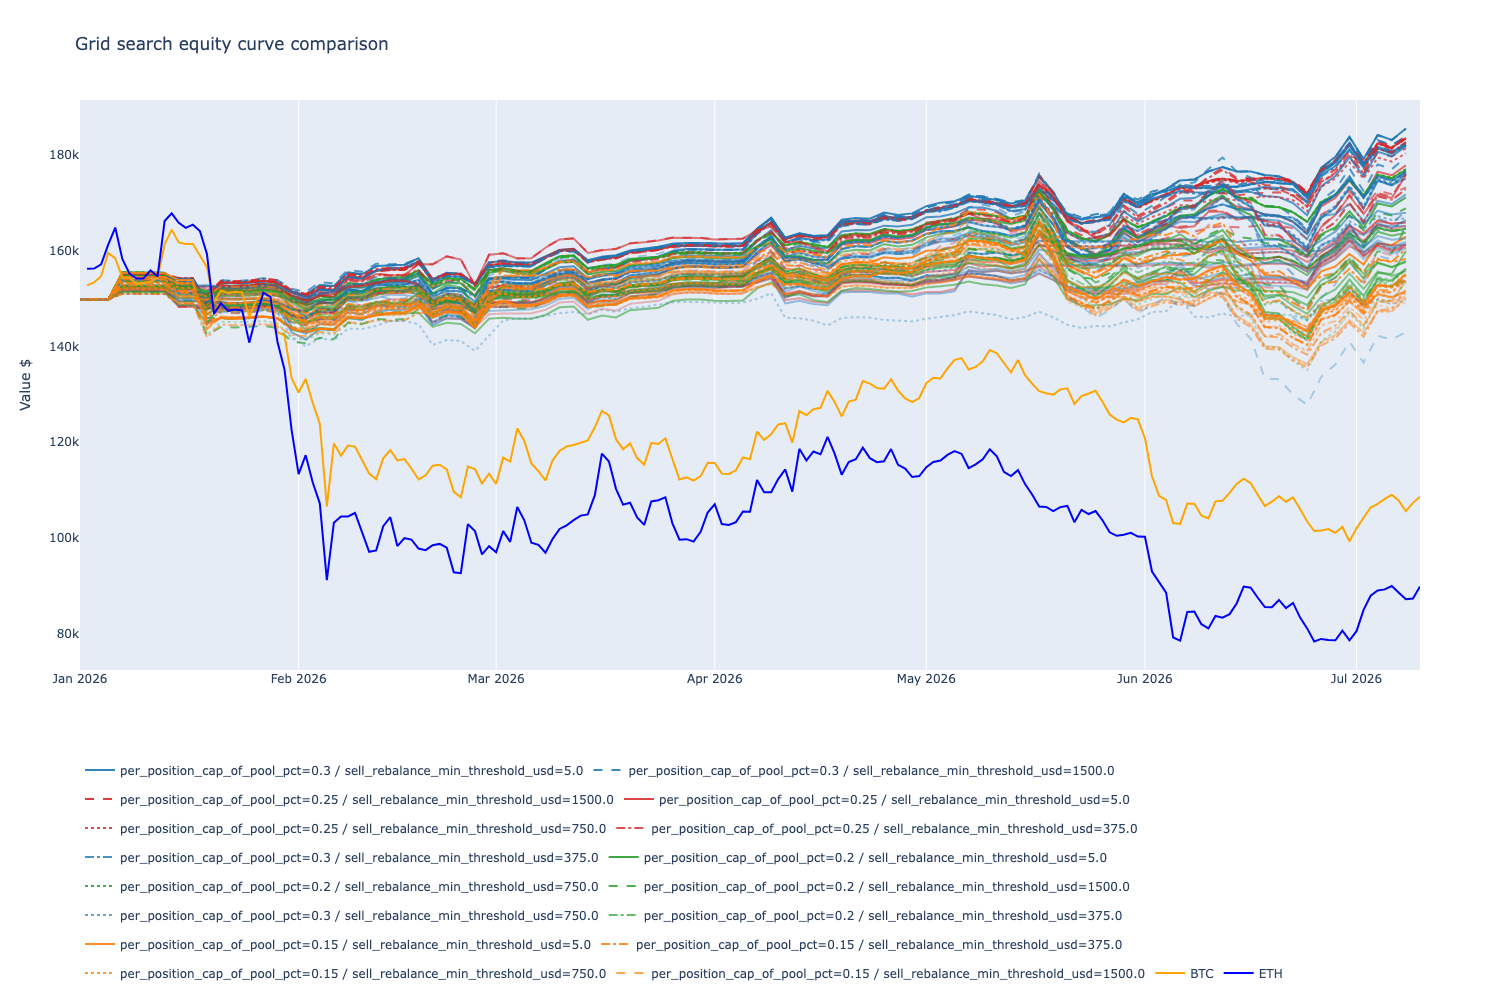

In [12]:
from tradeexecutor.visual.grid_search_basic import visualise_grid_search_equity_curves
from tradeexecutor.analysis.multi_asset_benchmark import get_benchmark_data

# Automatically create BTC and ETH buy and hold benchmark if present
# in the trading universe
benchmark_indexes = get_benchmark_data(
    strategy_universe,
    cumulative_with_initial_cash=Parameters.initial_cash,
    start_at=pd.Timestamp(Parameters.backtest_start),
)

# Extract GridSearchResult instances from optimiser results.
#
# `ignore_wallet_errors=True` turns a crashed backtest into a placeholder GridSearchResult whose
# equity curve is indexed at 1970-01-01/02 (see create_grid_search_failed_result). Those rows are
# not removed by `r.filtered`, which only reflects the MinTradeCountFilter, so leaving them in
# stretches the chart's x axis from 1970 to 2026 and flattens every real curve into a vertical line.
candidates = [r.result for r in optimiser_result.results if not r.filtered]
grid_search_results = [r for r in candidates if r.exception is None]
failed = len(candidates) - len(grid_search_results)
if failed:
    print(f"Excluding {failed} backtest(s) that failed with an exception from the equity curve chart")

fig = visualise_grid_search_equity_curves(
    grid_search_results,
    benchmark_indexes=benchmark_indexes,
    log_y=False,
    group_by="per_position_cap_of_pool_pct",
    group_by_secondary="sell_rebalance_min_threshold_usd",
)
fig.show()

# Parameter analysis

## Decision tree visualisation

Analysing Sharpe for parameters: ['inverse_vol_window', 'max_assets_in_portfolio', 'max_concentration_pct', 'per_position_cap_of_pool_pct', 'sell_rebalance_min_threshold_usd']


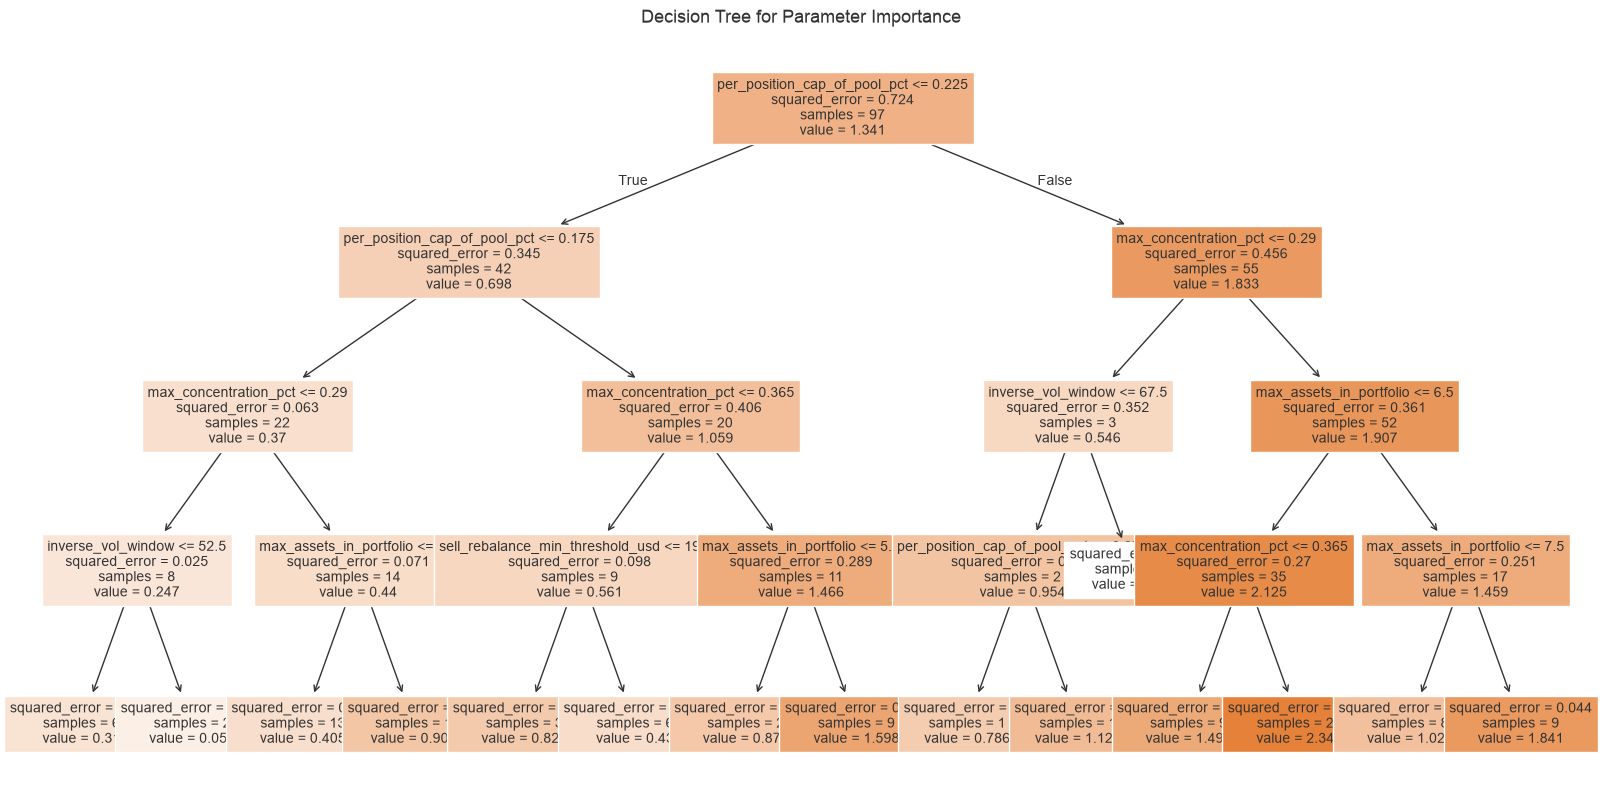

In [13]:
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor, plot_tree

parameter_names = list(df.index.names)
parameter_df = df
parameter_df = parameter_df.reset_index()

analysis_metric = "Sharpe"
print(f"Analysing {analysis_metric} for parameters: {parameter_names}")

# Prepare data
X = parameter_df[parameter_names]
y = parameter_df[analysis_metric]

# Convert categorical values if needed
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

# Train a simple decision tree
tree = DecisionTreeRegressor(max_depth=4)
tree.fit(X, y)

# Plot
plt.figure(figsize=(20, 10))
plot_tree(tree, feature_names=X.columns, filled=True, fontsize=10)
plt.title('Decision Tree for Parameter Importance')
plt.show()

## Feature importance analysis

Use a regression model to determine which parameters have the strongest influence.



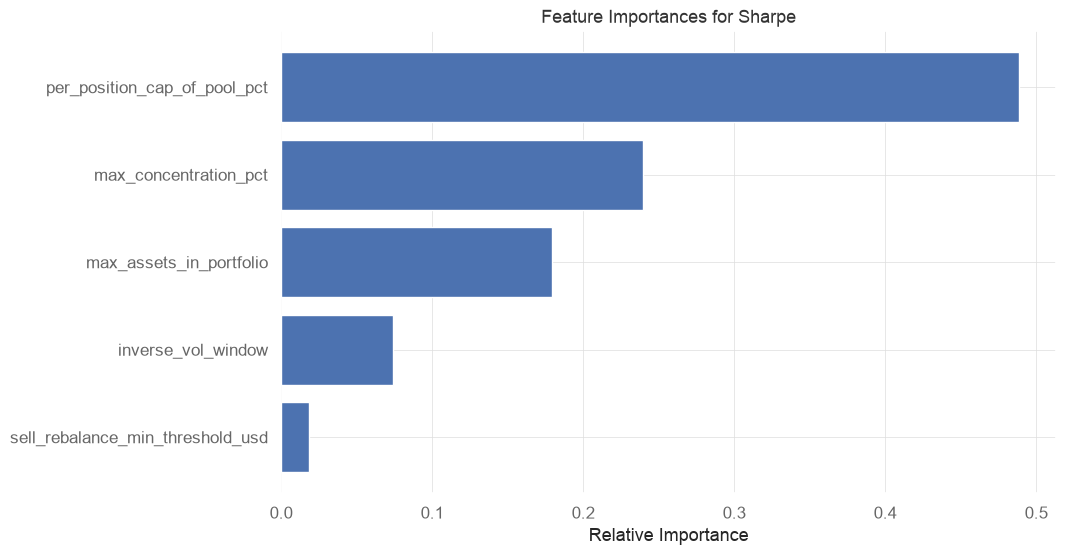

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
X = parameter_df[parameter_names]
y = parameter_df[analysis_metric]

# Convert categorical values to numeric if needed
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

# Train a random forest model
model = RandomForestRegressor(n_estimators=100)
model.fit(X, y)

# Plot feature importances
importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title(f'Feature Importances for {analysis_metric}')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

## Heatmaps for parameter pairs

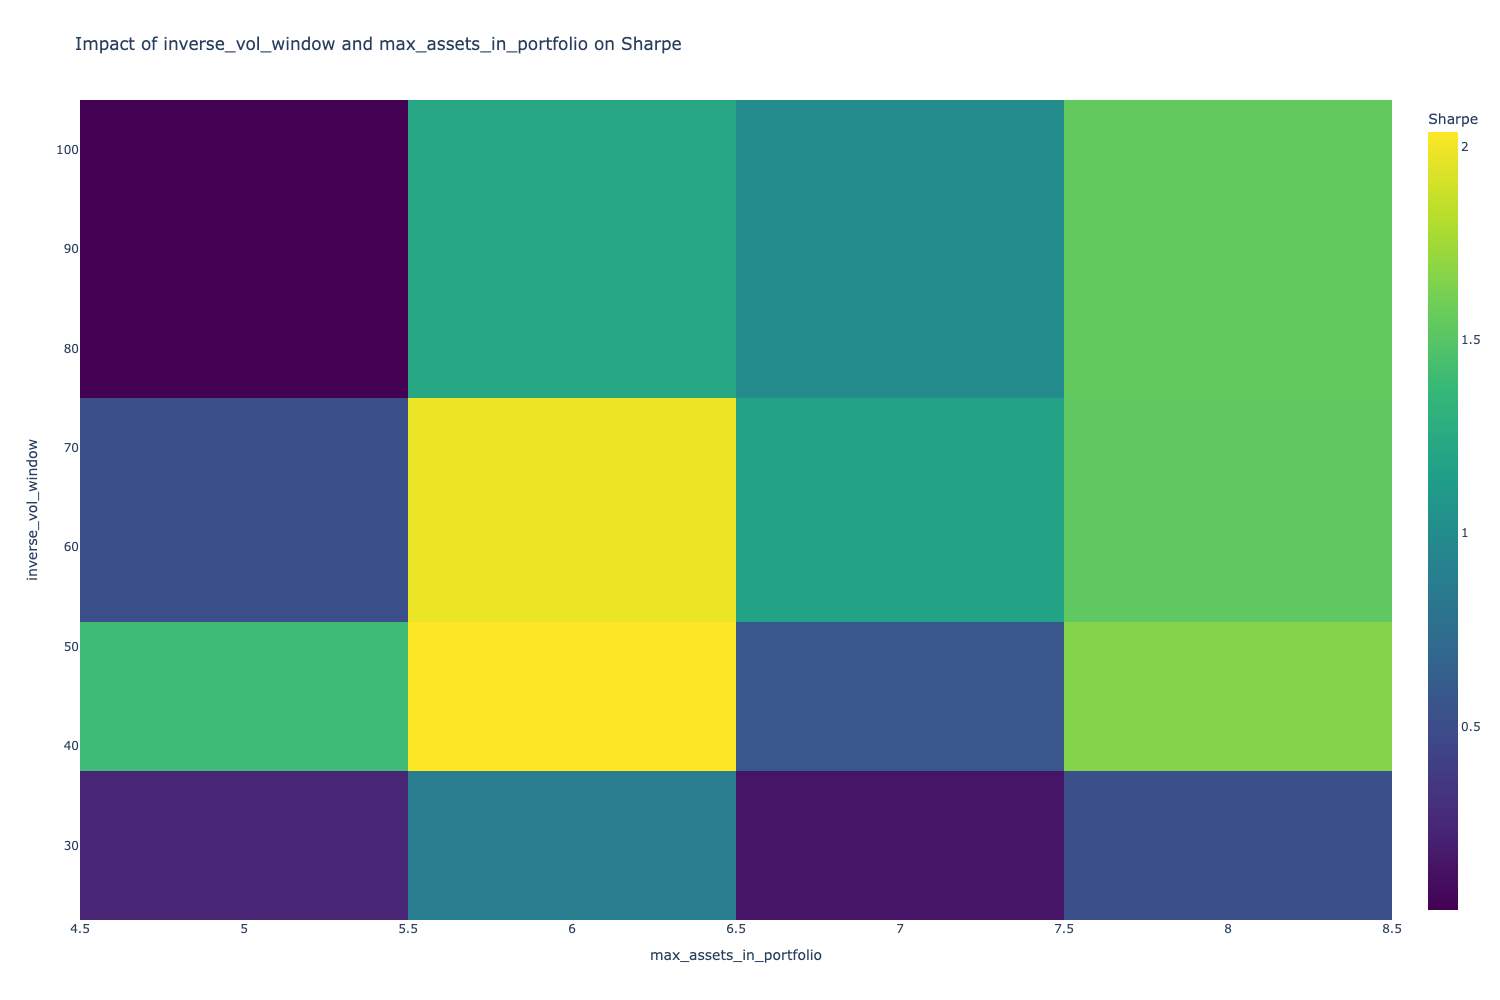

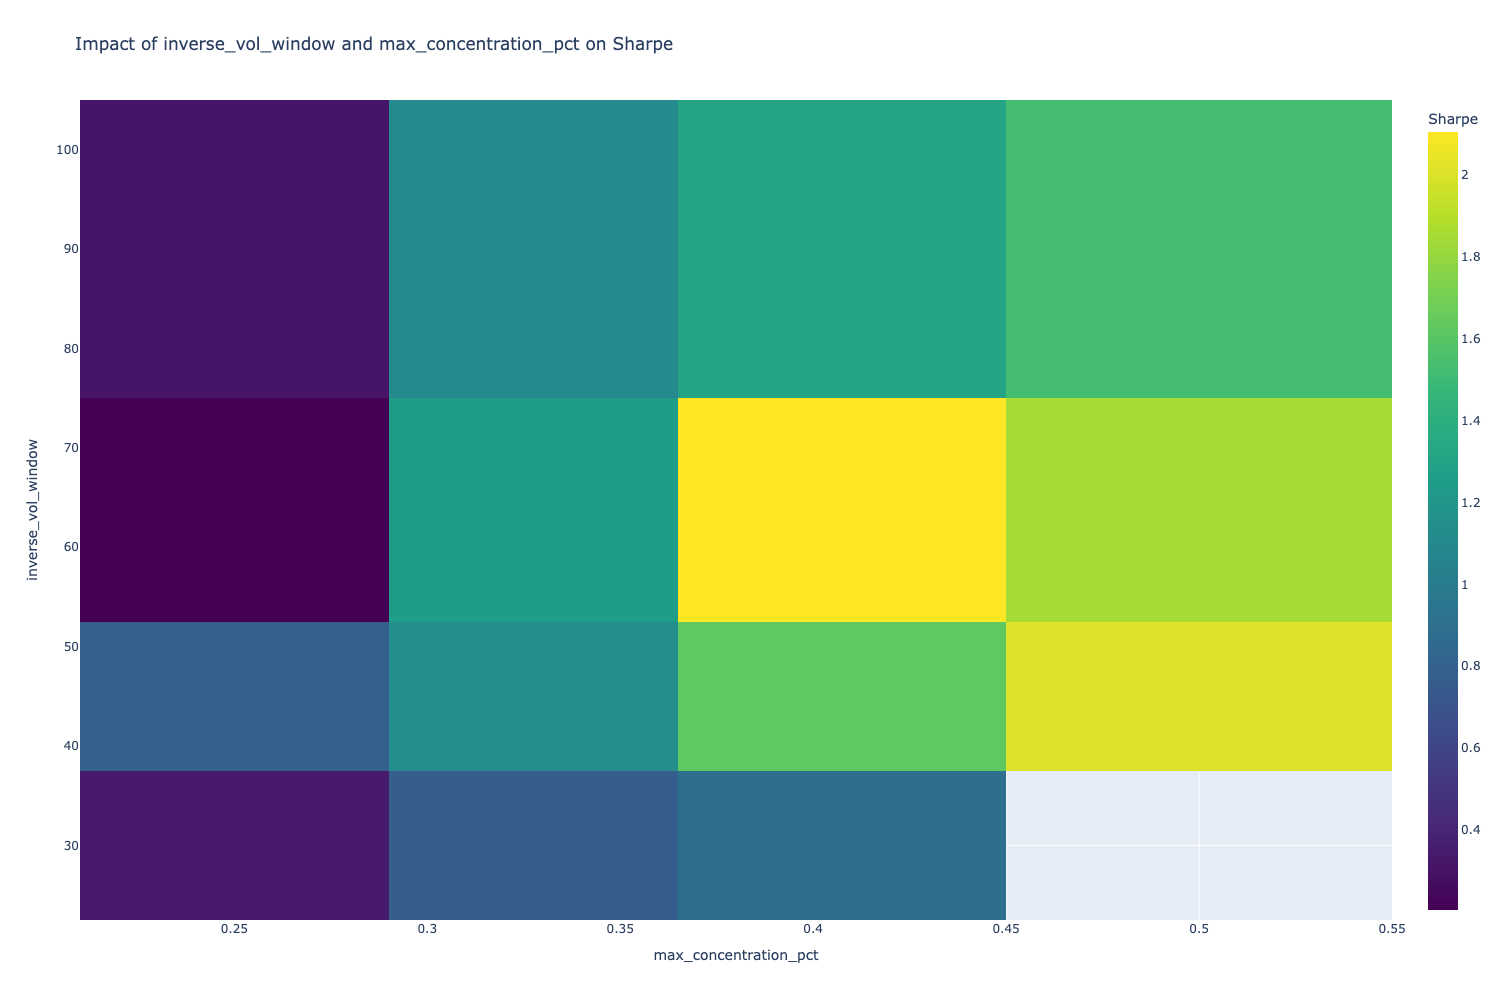

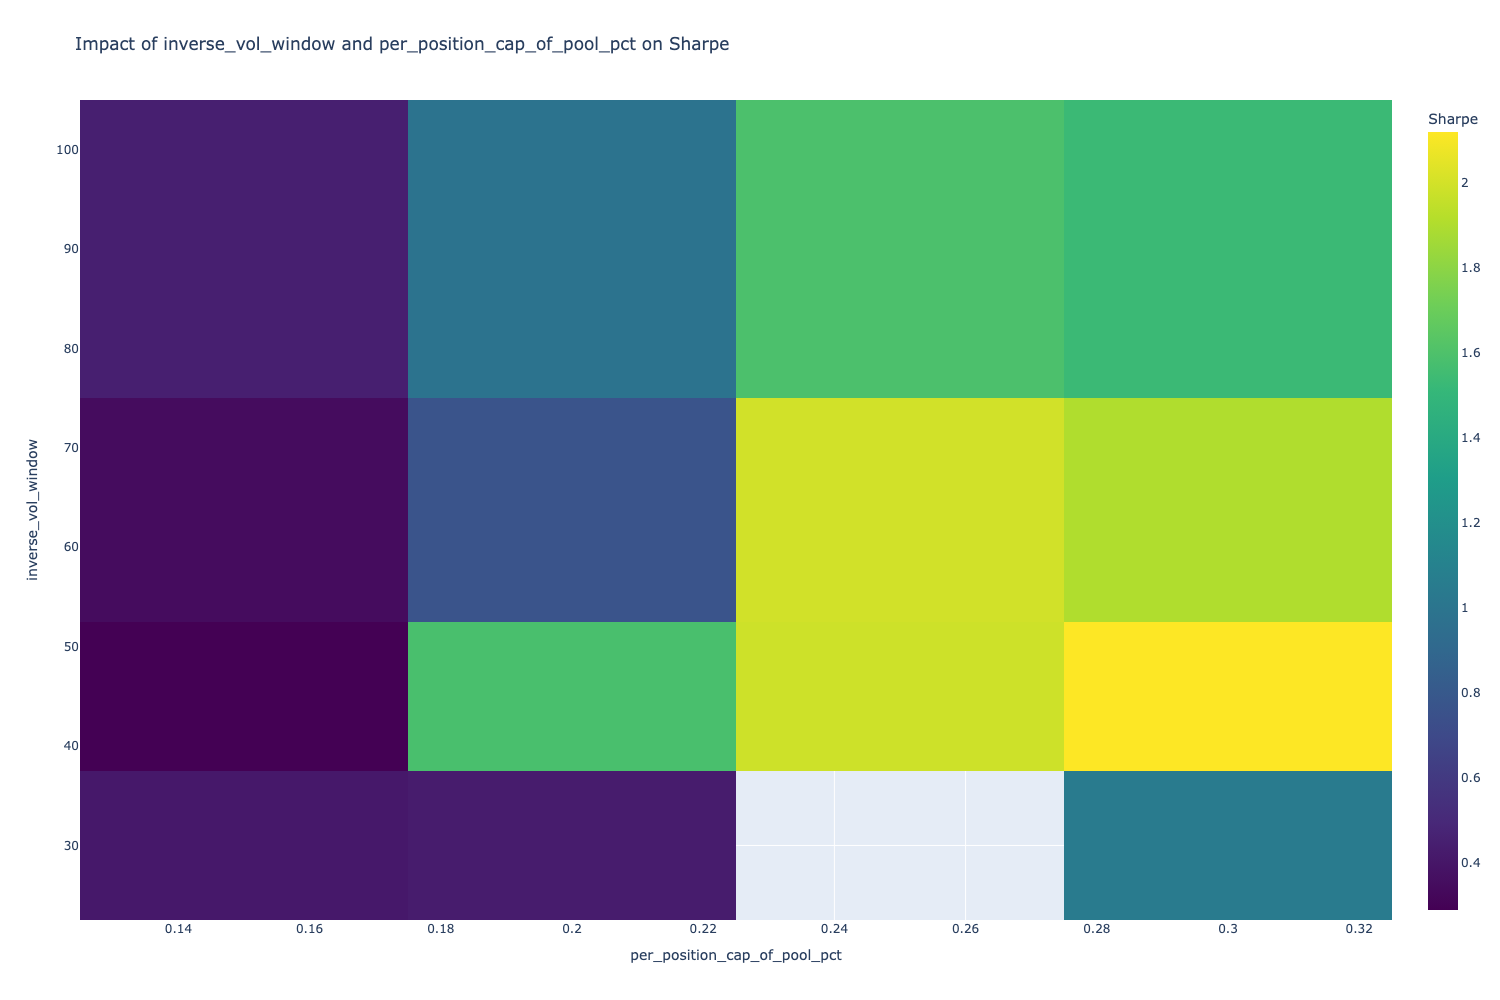

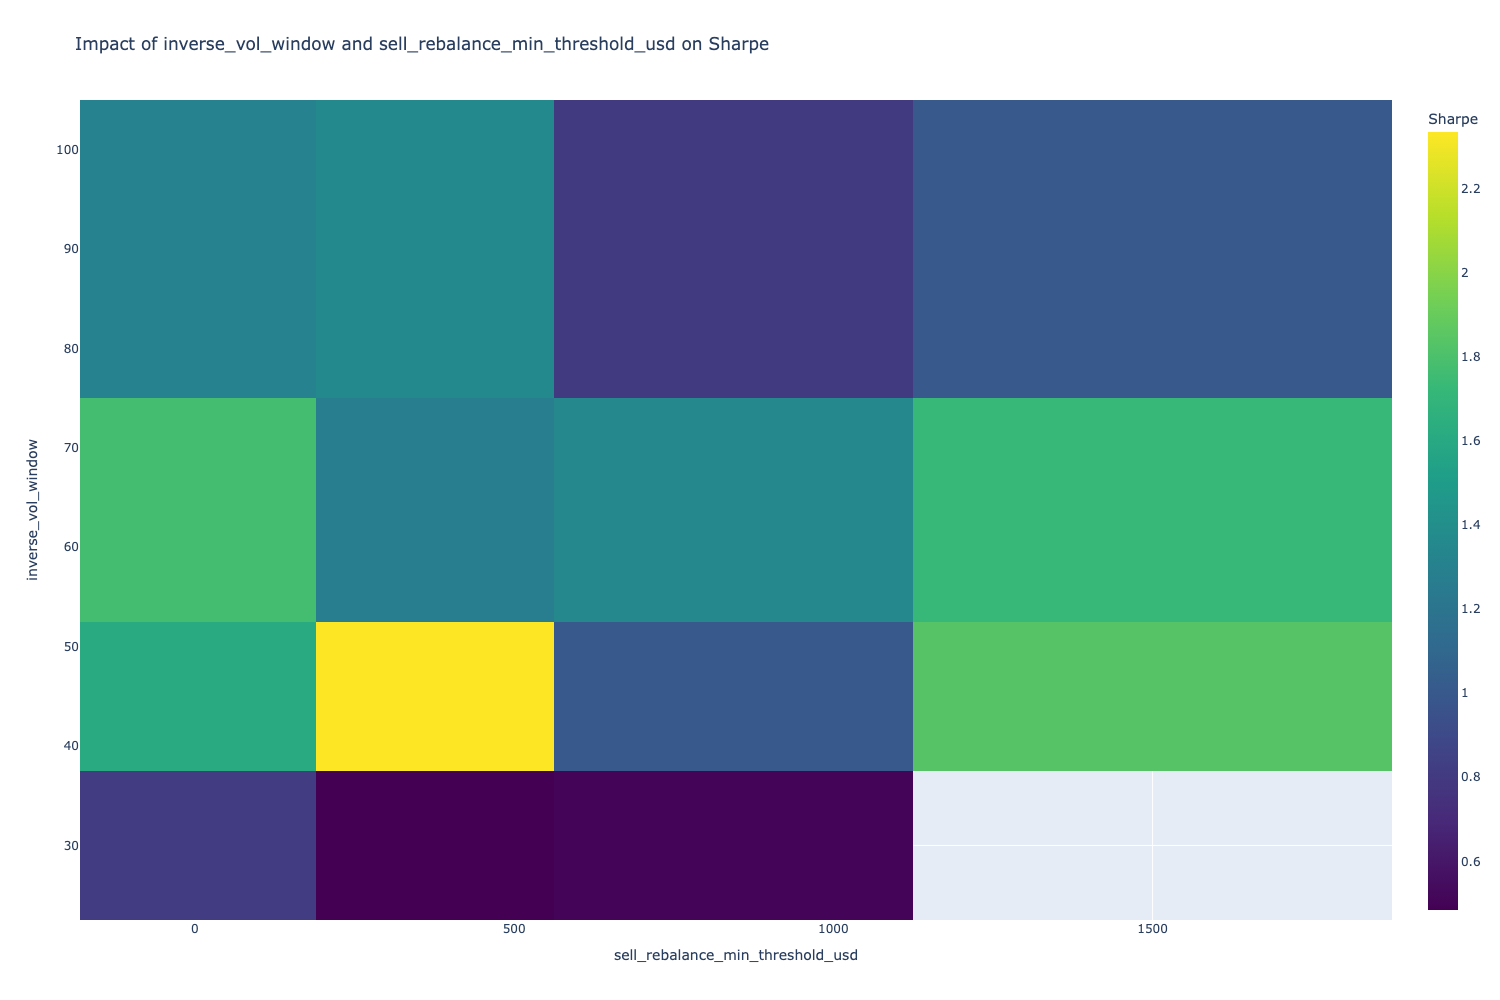

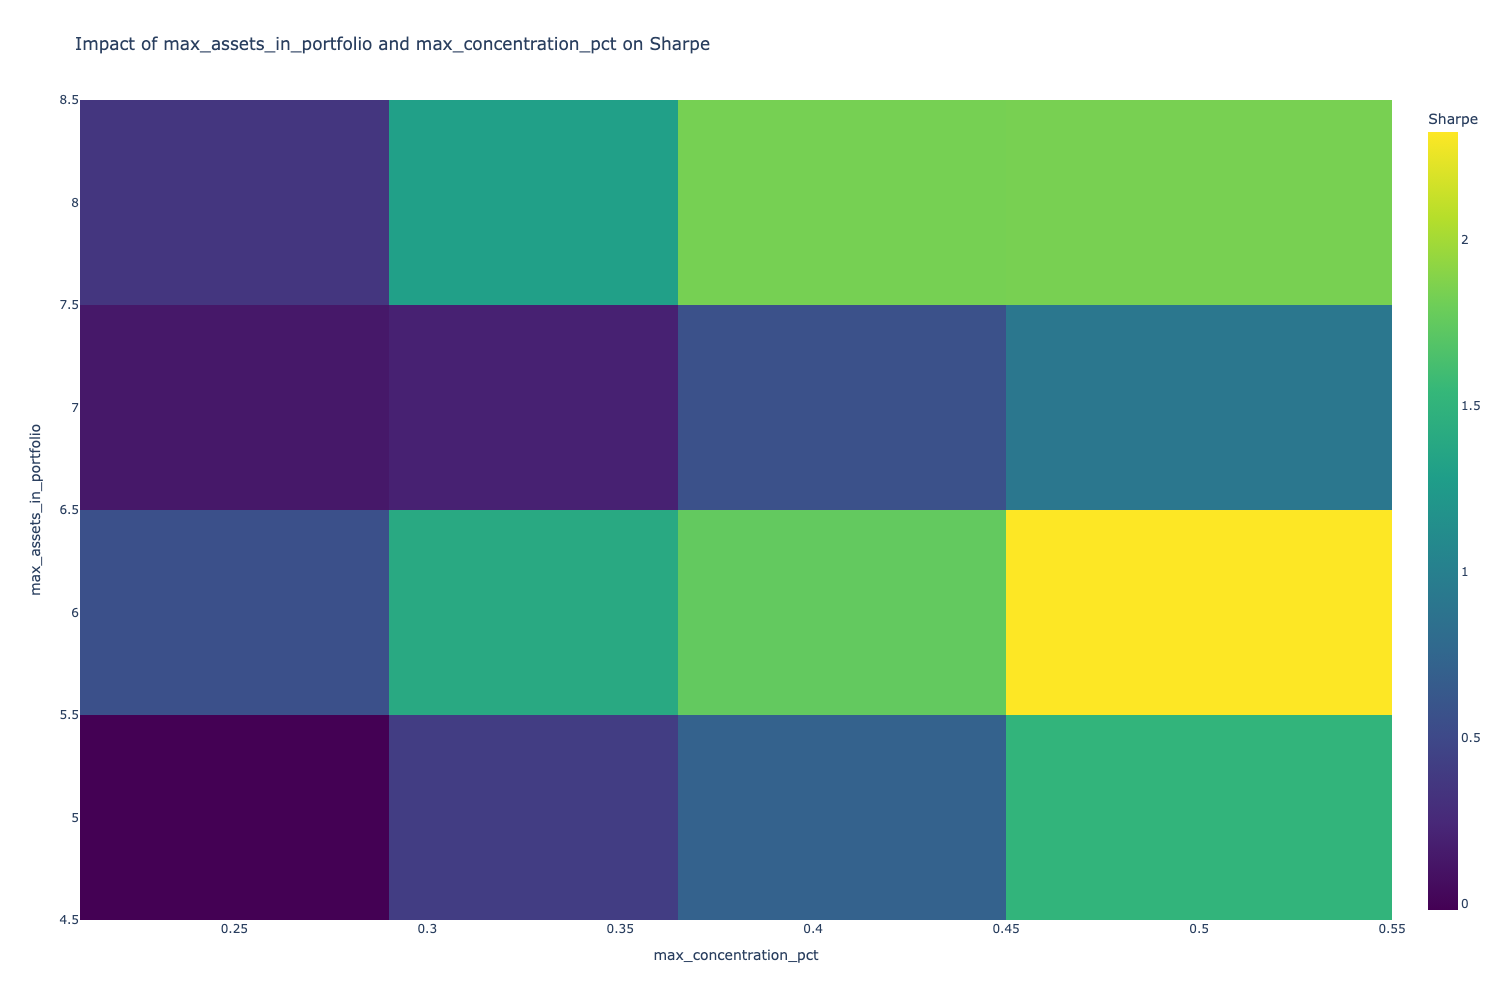

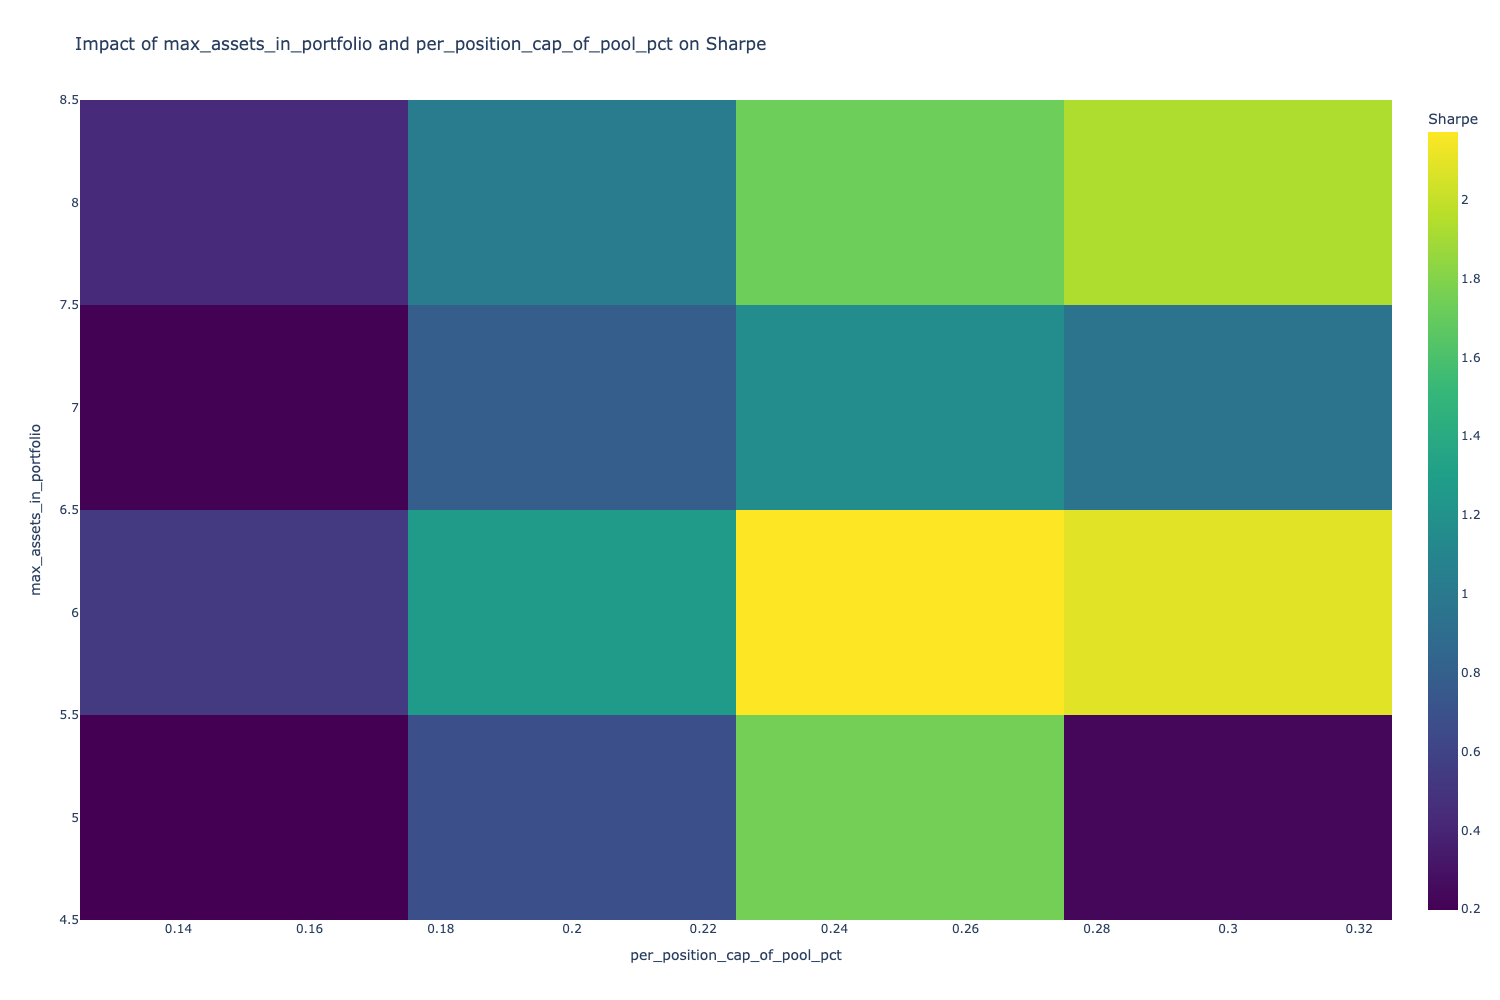

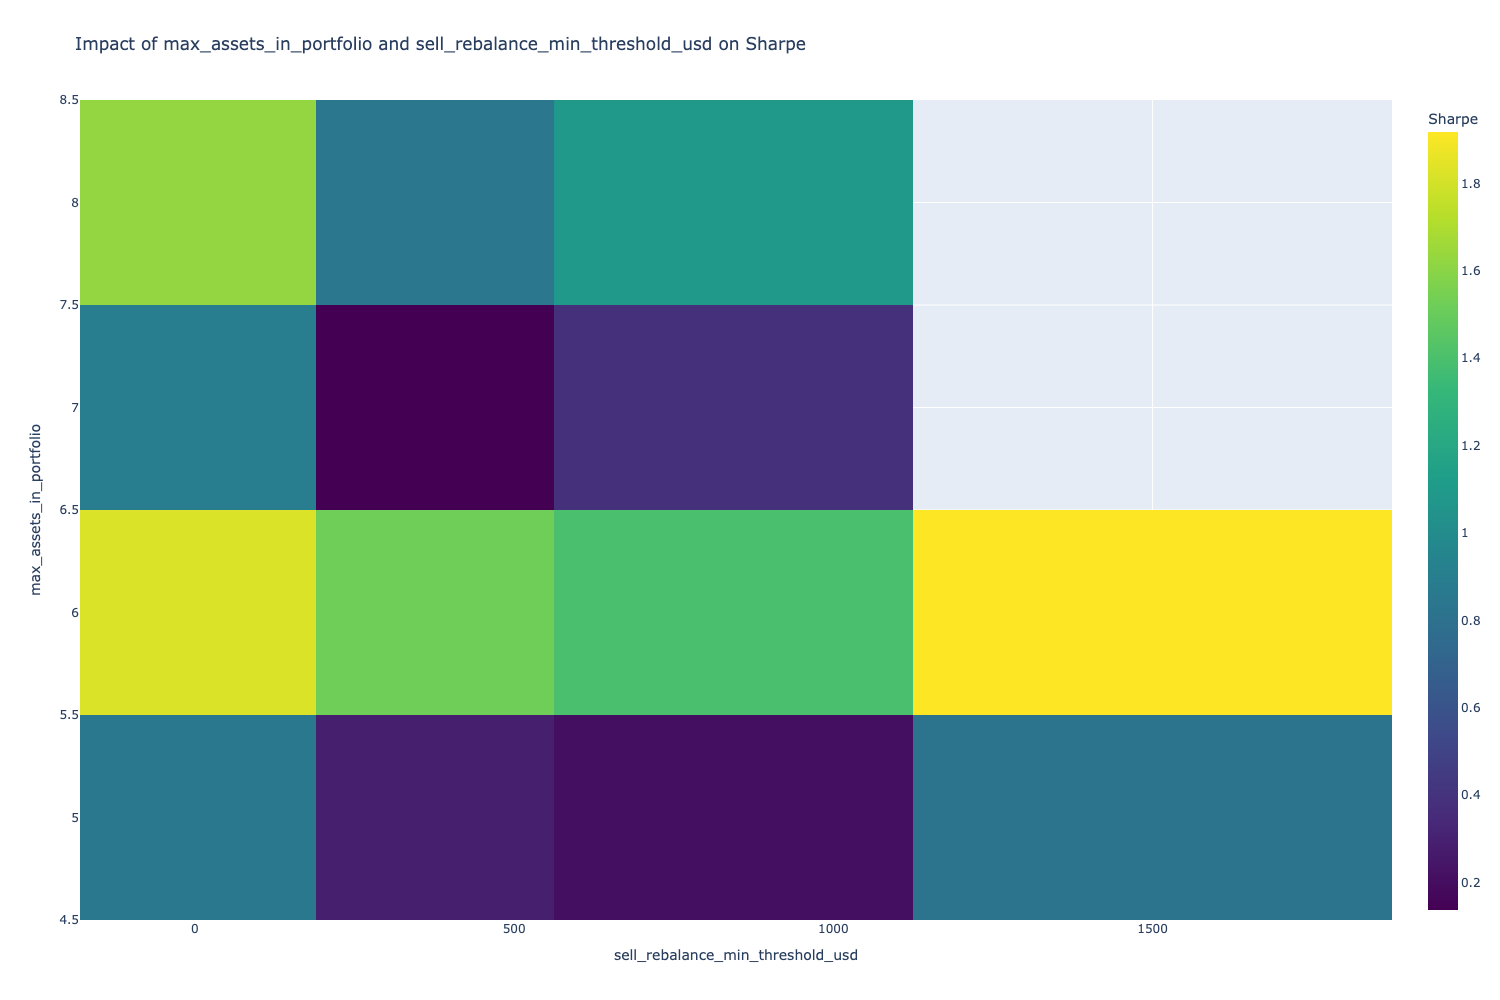

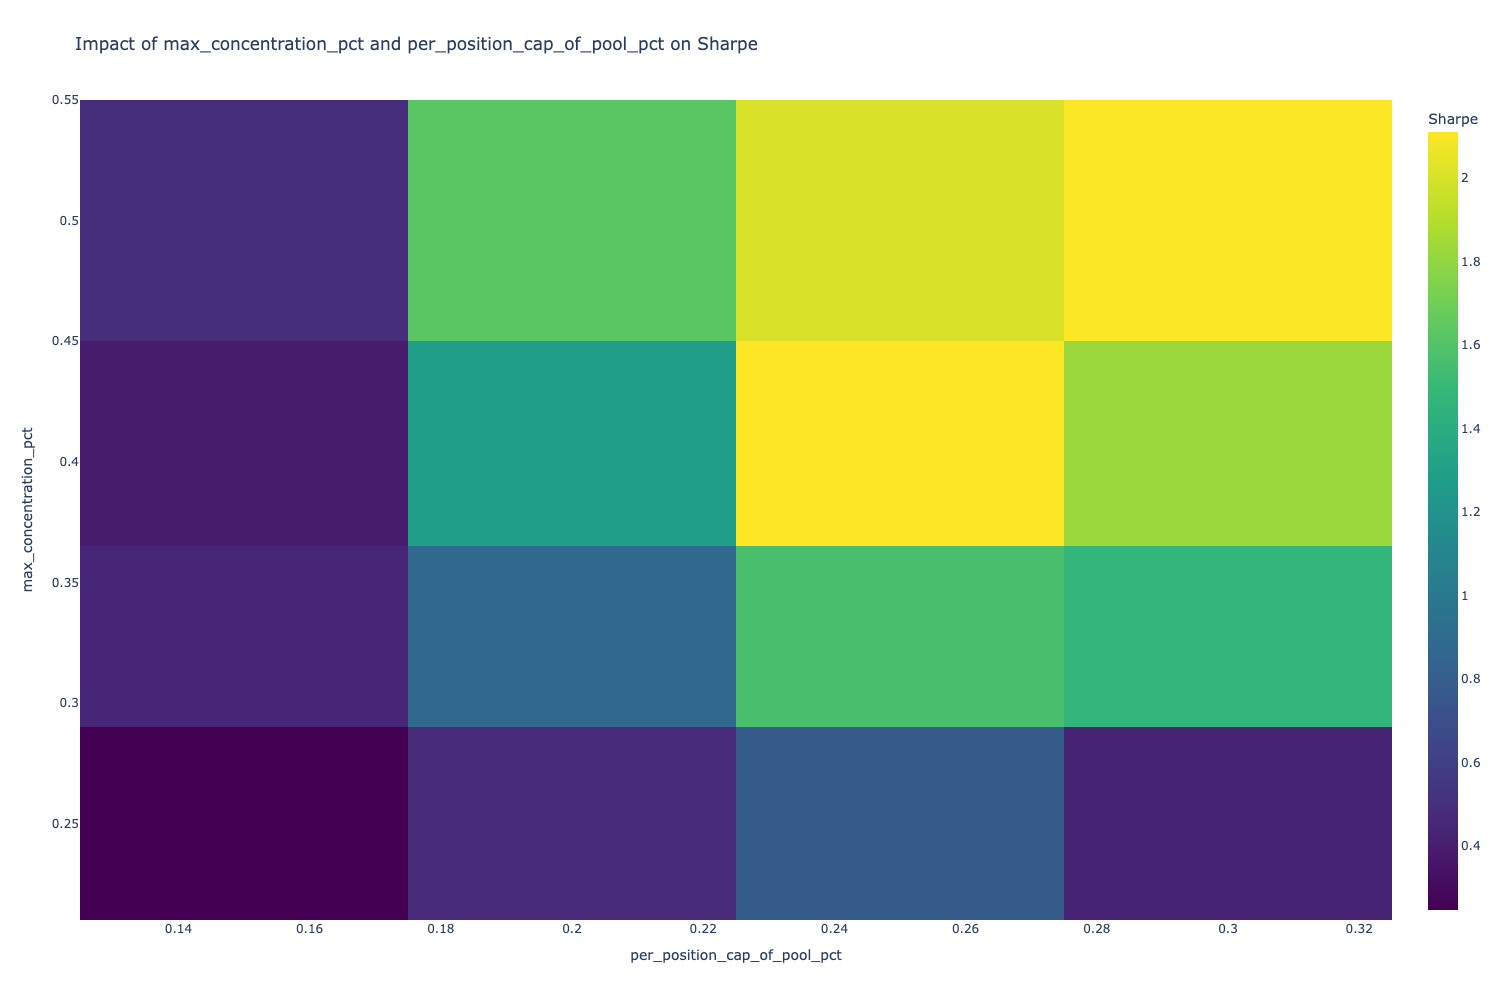

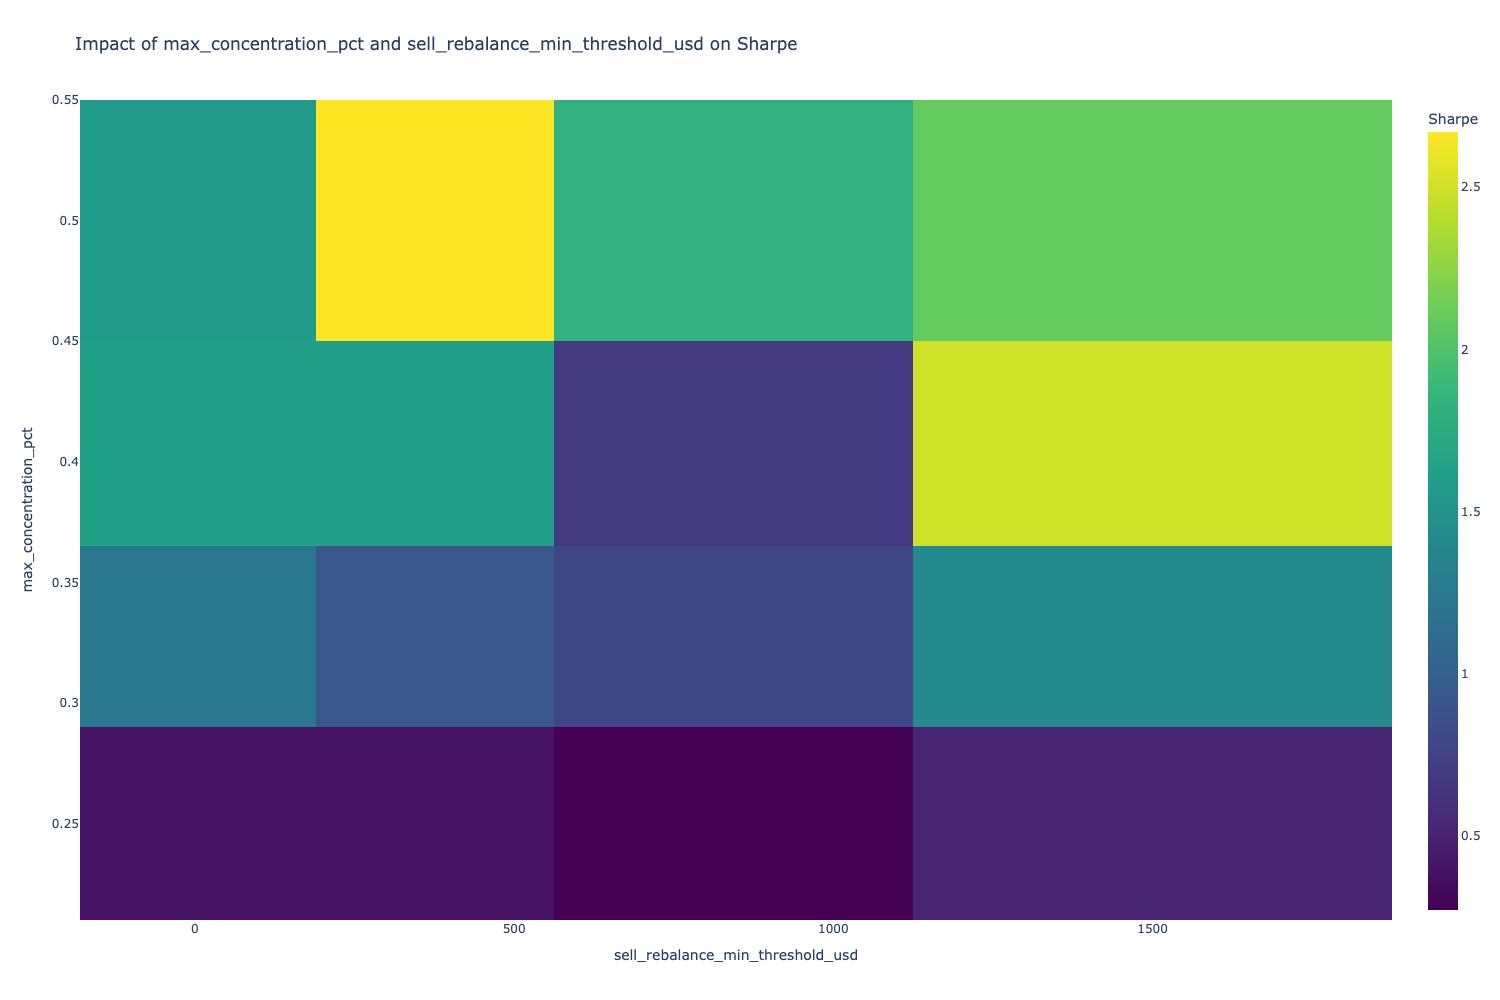

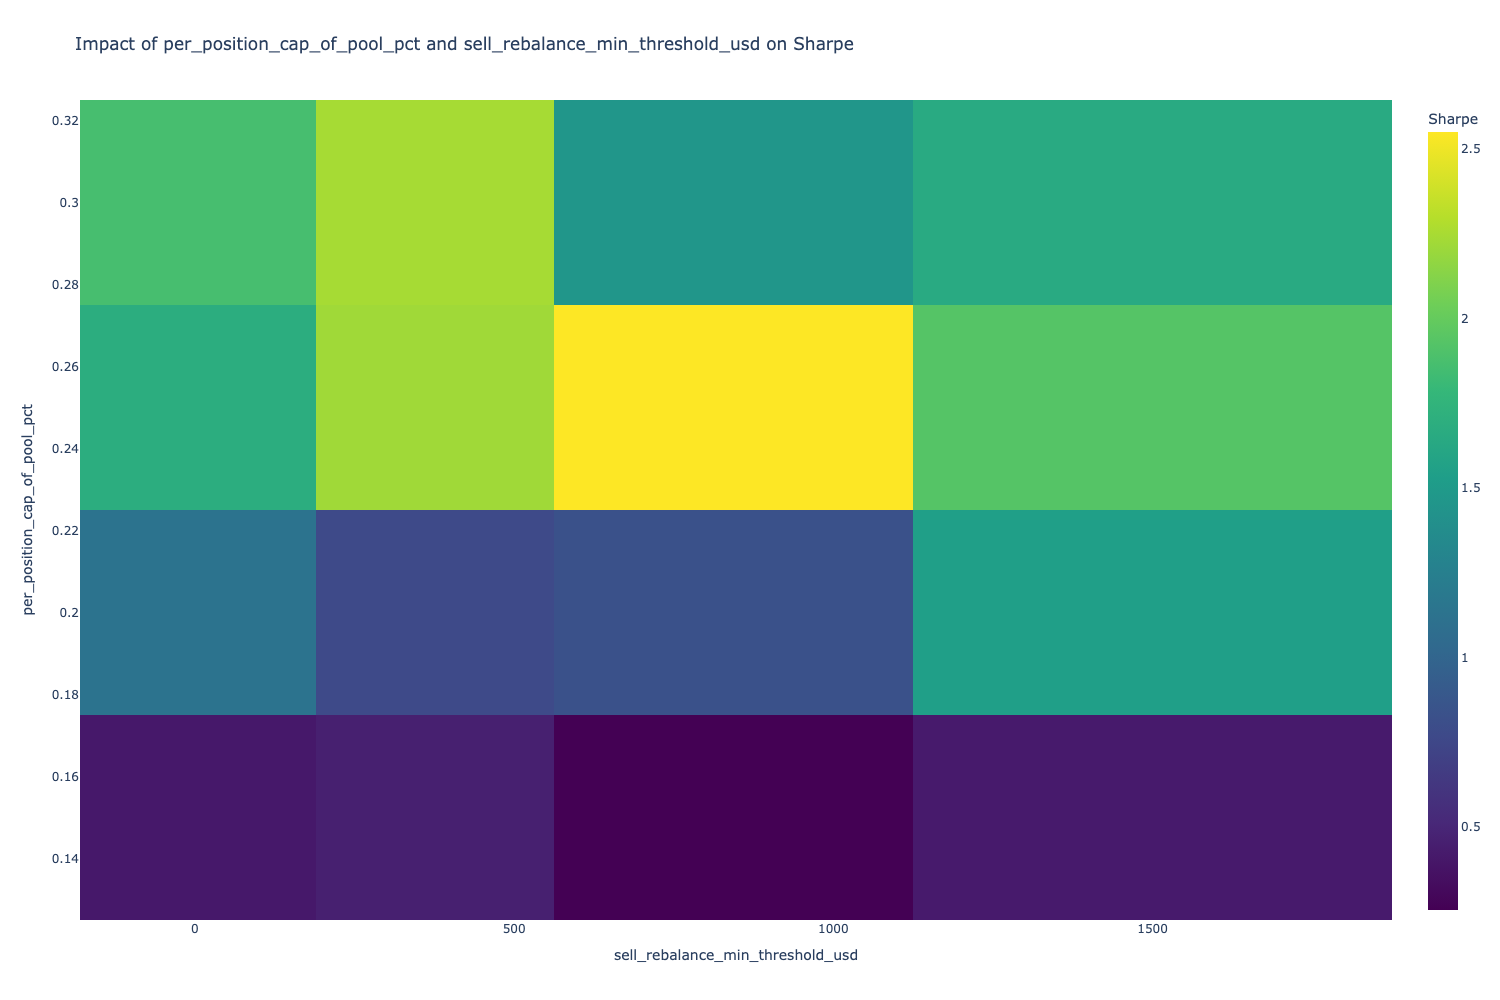

In [15]:
import plotly.graph_objects as go
import numpy as np

def create_heatmap(df, param1, param2, metric):
    # Create pivot table
    pivot = df.pivot_table(
        values=metric, 
        index=param1,
        columns=param2,
        aggfunc="mean"
    )
    
    fig = go.Figure(data=go.Heatmap(
        z=pivot.values,
        x=pivot.columns,
        y=pivot.index,
        colorscale='Viridis',
        colorbar=dict(title=metric)
    ))
    
    fig.update_layout(
        title=f'Impact of {param1} and {param2} on {metric}',
        xaxis_title=param2,
        yaxis_title=param1
    )
    
    return fig

# All parameter pairs, not just consecutive ones - the consecutive-only loop skipped
# hold x softband entirely.
from itertools import combinations

param_pairs = list(combinations(parameter_names, 2))

for param1, param2 in param_pairs:
    fig = create_heatmap(parameter_df, param1, param2, metric=analysis_metric)
    fig.show()

## Cluster analysis

cluster      CAGR                              Sharpe                      \
               mean       min       max count      mean       min       max   
0       0  0.309985 -0.000070  0.514683    18  1.724491  0.066767  2.605622   
1       1  0.102915 -0.008945  0.219802    17  0.845285  0.016270  1.899465   
2       2  0.282278  0.019367  0.482908    26  1.766098  0.212927  2.739046   
3       3  0.332031 -0.087016  0.514139    17  1.745746 -0.270060  2.756616   
4       4  0.078503  0.001927  0.294954    19  0.479622  0.100848  1.540163   

     Max DD                      
       mean       min       max  
0 -0.064524 -0.089540 -0.034916  
1 -0.090521 -0.148639 -0.033875  
2 -0.053341 -0.088811 -0.032652  
3 -0.092211 -0.231801 -0.036539  
4 -0.150597 -0.186474 -0.080503

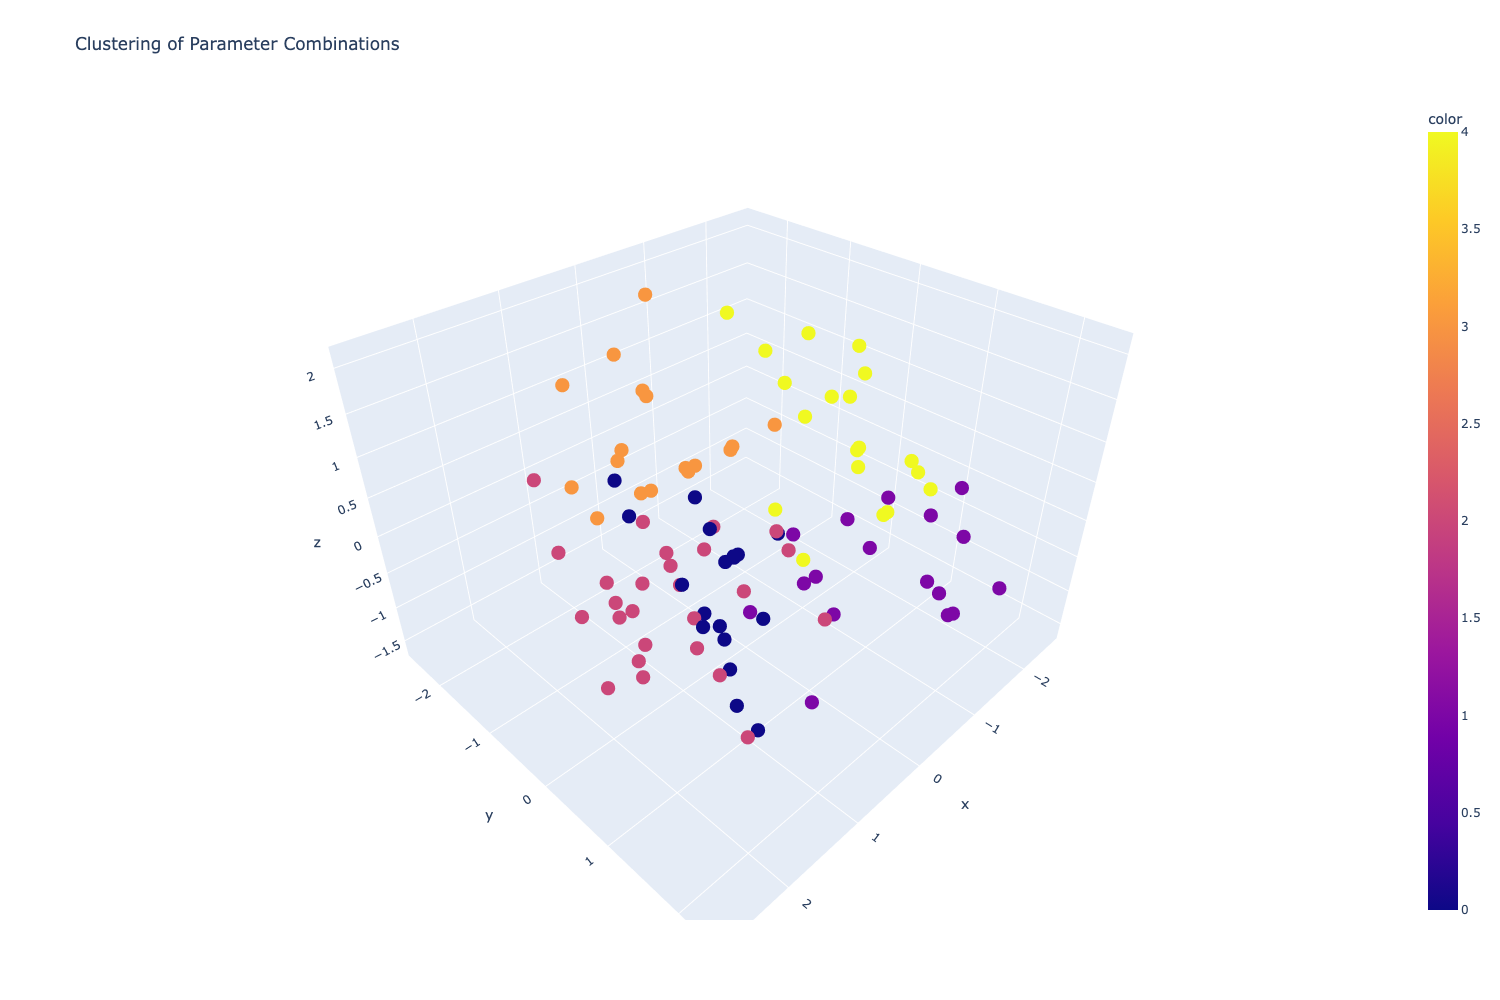

In [16]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import plotly.express as px

# Select features for clustering
features = parameter_names
X = parameter_df[features]

# Convert categorical values to numeric
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-means clustering (determine optimal k separately)
kmeans = KMeans(n_clusters=5, random_state=42)
parameter_df['cluster'] = kmeans.fit_predict(X_scaled)

# Analyze performance by cluster
cluster_perf = parameter_df.groupby('cluster').agg({
    'CAGR': ['mean', 'min', 'max', 'count'],
    'Sharpe': ['mean', 'min', 'max'],
    'Max DD': ['mean', 'min', 'max']
}).reset_index()

display(cluster_perf)

# Visualize clusters in 3D space (using first 3 PCA components)
from sklearn.decomposition import PCA

try:
    pca = PCA(n_components=3)
    components = pca.fit_transform(X_scaled)

    fig = px.scatter_3d(
        x=components[:, 0],
        y=components[:, 1],
        z=components[:, 2],
        color=parameter_df['cluster'],
        hover_data={'Sharpe': parameter_df['Sharpe'], 'CAGR': parameter_df['CAGR']},
        title='Clustering of Parameter Combinations'
    )
    fig.show()
except ValueError as e:
    print(f"Error in PCA: {e}")
    print("PCA failed, possibly due to too few features or singular matrix.")
    # Handle the error as needed

## Parallel coordinates plot

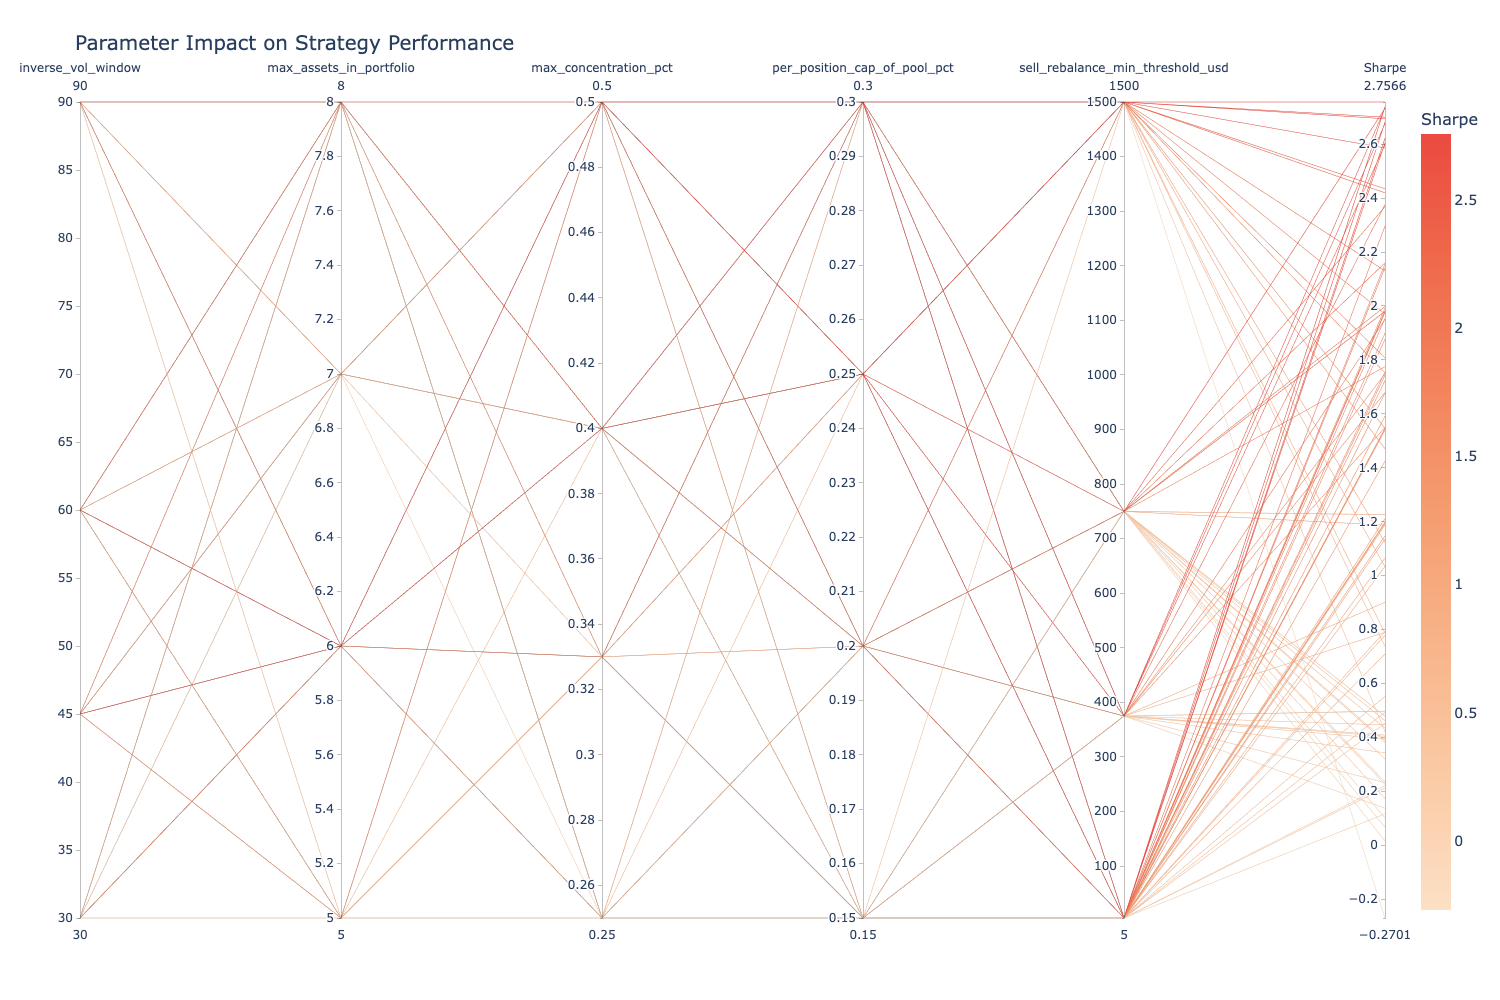

In [17]:
import plotly.express as px

# Extract top results (e.g., top 50)
top_results = parameter_df.head(50)

dimensions = parameter_names + [analysis_metric]

# Create parallel coordinates plot
fig = px.parallel_coordinates(
    parameter_df,
    dimensions=dimensions,
    color=analysis_metric,
    color_continuous_scale=px.colors.sequential.Peach,
    title='Parameter Impact on Strategy Performance'
)


# Increase font size for axis titles, tick labels, and title
fig.update_layout(
    font=dict(size=14),  # Base font size for the whole figure
    title=dict(
        text='Parameter Impact on Strategy Performance',
        font=dict(size=20)  # Title font size
    ),
    coloraxis_colorbar=dict(
        title=dict(
            text=analysis_metric,
            font=dict(size=16)
        ),
        tickfont=dict(size=14)
    )
)

# Parallel coordinates chart: Line width not supported
# https://github.com/plotly/plotly.js/issues/2573

fig.show()

# The best candidate equity curve

The best result found for <function optimise_sharpe at 0x12f88a770> was <GridSearchResult
  #31, inverse_vol_window=45, max_assets_in_portfolio=6, max_concentration_pct=0.5, per_position_cap_of_pool_pct=0.25, sell_rebalance_min_threshold_usd=1500.0
  CAGR: 49.00%, Sharpe: 2.76, Sortino: 4.78, Max drawdown:-5.00%
>


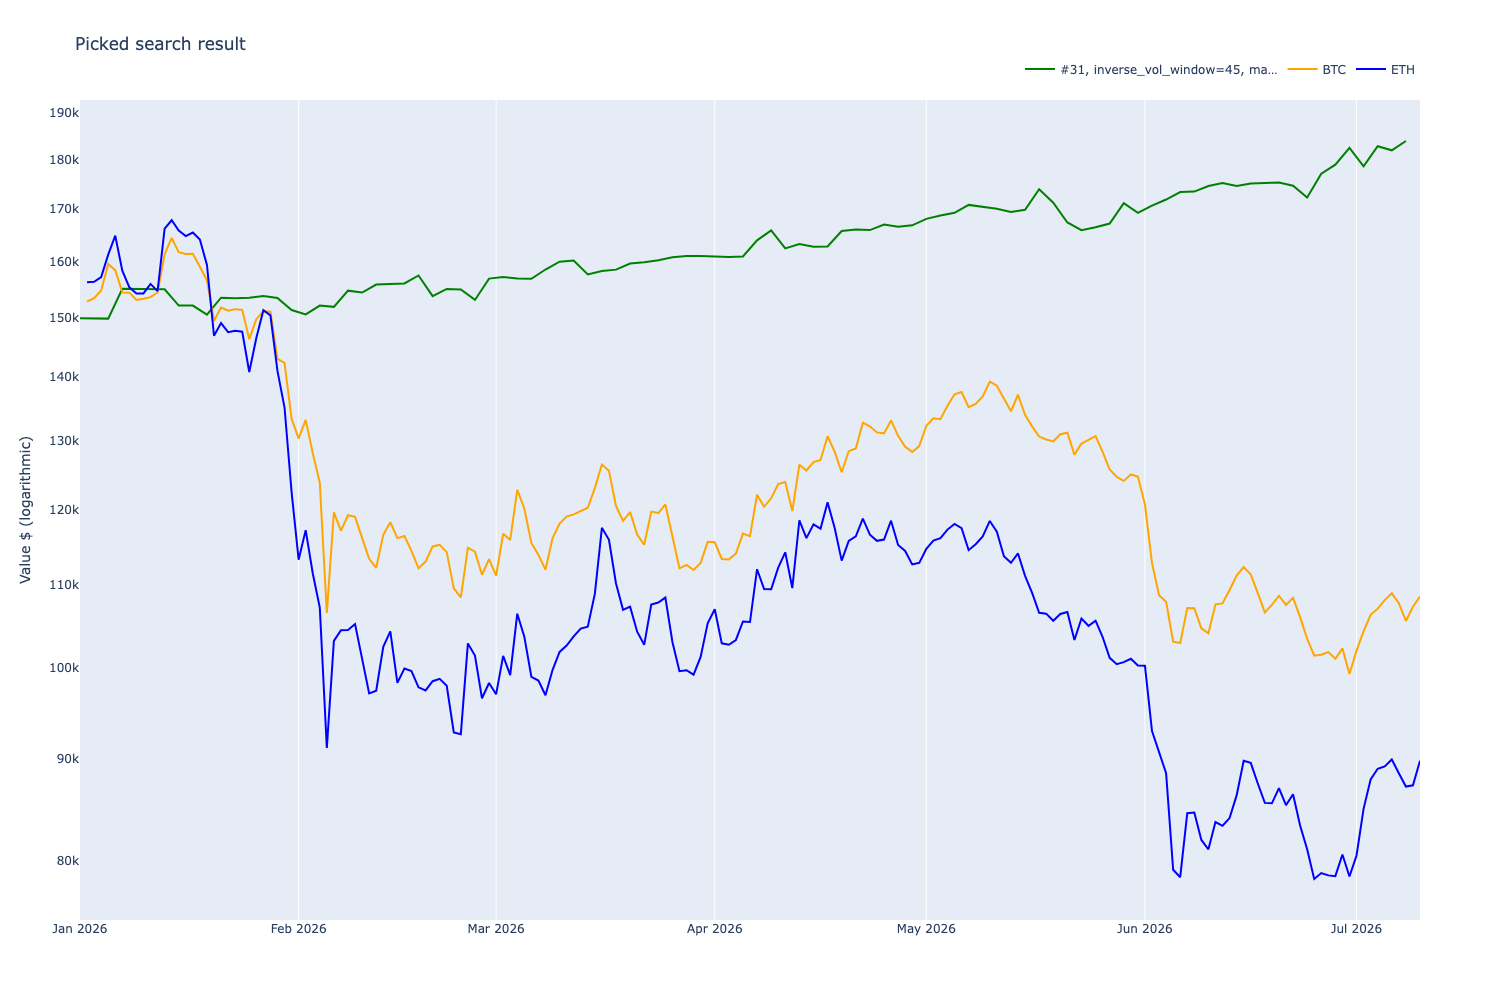

In [18]:
from tradeexecutor.visual.grid_search import visualise_single_grid_search_result_benchmark

# GridSearchResult instance that gave the best performance
best_pick = next(result.result for result in optimiser_result.results if not result.filtered)
state = best_pick.hydrate_state()

print(f"The best result found for {search_func} was {best_pick}")

fig = visualise_single_grid_search_result_benchmark(
    best_pick, 
    strategy_universe, 
    initial_cash=Parameters.initial_cash,
    log_y=True,
)
fig.show()

# Portfolio performance (best pick)

- Compare buy and hold against our best performance

In [19]:
from tradeexecutor.analysis.multi_asset_benchmark import compare_strategy_backtest_to_multiple_assets

returns = best_pick.returns

df = compare_strategy_backtest_to_multiple_assets(
    state=state,
    strategy_universe=strategy_universe,
    returns=returns,
    display=True,
    asset_count=3,
)
display(df)

,Strategy,BTC,ETH
Start Period,2026-01-01,2026-01-01,2026-01-01
End Period,2026-07-08,2026-07-08,2026-07-08
Risk-Free Rate,0.0%,0.0%,0.0%
Time in Market,49.0%,98.0%,98.0%
Cumulative Return,22.77%,-31.79%,-44.56%
CAGR﹪,48.92%,-52.42%,-68.18%
Sharpe,2.76,-1.28,-1.43
Prob. Sharpe Ratio,98.08%,17.96%,15.34%
Smart Sharpe,2.7,-1.25,-1.4
Sortino,4.78,-1.72,-1.93


# Trade summary (best pick)

- Show statistics about the made trades

In [20]:
summary = best_pick.summary
display(summary.to_dataframe())

,0
Trading period length,188 days 0 hours
Trading start,None
Trading end,None
Return %,22.65%
Annualised return %,43.97%
Cash at start,"$150,000.00"
Value at end,"$183,970.40"
Time in market,0.00%
Time in market volatile,0.00%
Trade volume,"$4,156,037.36"


# Trading pair performance breakdown

- Show breakdown of different pairs on the best result

In [21]:
from tradeexecutor.analysis.multipair import analyse_multipair
from tradeexecutor.analysis.multipair import format_multipair_summary

# Zero-duration positions: opened and closed inside the same decision cycle.
#
# `analyse_multipair()` asserts every position has a positive duration, so one of these aborts the
# whole analysis. They are a real artefact of a 2-day cadence, not a reporting nuisance: the
# strategy opened a vault position and unwound it before the next decision point, paying the 10 BPS
# exit fee for no holding period at all. Report them, then run the analysis on what remains.
zero_duration = [
    p for p in state.portfolio.get_all_positions()
    if p.closed_at is not None and p.opened_at is not None and p.closed_at <= p.opened_at
]

if zero_duration:
    print(f"{len(zero_duration)} position(s) opened and closed within one cycle:")
    display(pd.DataFrame([{
        "Vault": p.pair.base.token_symbol,
        "Opened": p.opened_at,
        "Closed": p.closed_at,
        "Realised profit USD": float(p.get_realised_profit_usd() or 0.0),
        "Trades": p.get_trade_count(),
    } for p in zero_duration]).style.format({"Realised profit USD": "${:,.2f}"}).set_caption(
        "Positions with no holding period - they pay the exit fee and cannot earn vault yield"
    ))
    print("These are excluded from the multipair summary below because "
          "analyse_multipair() asserts on them.")

try:
    multipair_summary = analyse_multipair(state)
    display(format_multipair_summary(multipair_summary))
except AssertionError as exc:
    print(f"Multipair summary unavailable: {exc}")
    print("This is the zero-duration position issue above, not a data problem.")


,Trading pair,Positions,Trades,Total return %,Total PnL USD,Best,Worst,Avg,Median,Volume,Wins,Losses,Take profits,Stop losses,Trailing stop losses,Volatility
3,Scared Money,6,26,66.53%,"7,449.16",23.06%,-0.89%,11.09%,14.10%,"115,449.98",4,2,0,0,0,8.76%
2,Realist Capital,3,43,45.52%,"17,251.60",22.60%,3.30%,15.17%,19.62%,"380,028.25",3,0,0,0,0,8.48%
24,HyperProfit {PRO},2,5,25.82%,592.17,23.73%,2.10%,12.91%,12.91%,"10,789.78",2,0,0,0,0,10.81%
0,Goon Edging,4,24,23.65%,"7,559.01",16.22%,-12.10%,5.91%,9.77%,"142,736.31",3,1,0,0,0,11.35%
7,Growi HF,1,4,6.11%,"3,630.12",6.11%,6.11%,6.11%,6.11%,"122,385.46",1,0,0,0,0,0.00%
1,Mad Scientists,1,5,3.53%,500.41,3.53%,3.53%,3.53%,3.53%,"14,168.15",1,0,0,0,0,0.00%
18,Gucky_1coin_1dot5x,1,22,1.42%,591.83,1.42%,1.42%,1.42%,1.42%,"83,949.70",1,0,0,0,0,0.00%
9,Mahamor,2,4,1.15%,66.89,1.25%,-0.10%,0.57%,0.57%,"23,578.06",1,1,0,0,0,0.67%
5,pmalt,4,58,0.93%,"7,419.60",2.60%,-1.49%,0.23%,-0.09%,"823,039.68",1,3,0,0,0,1.48%
4,69 Jump Street,4,16,0.93%,693.20,0.85%,-0.17%,0.23%,0.13%,"508,777.23",2,2,0,0,0,0.41%


# Best positions

- Find positions that made most profit for the leading backtest

In [22]:
profit_by_position = [(p.get_realised_profit_usd(), p) for p in state.portfolio.get_all_positions()]
profit_by_position.sort(key=lambda t: t[0] or -999_999_999, reverse=True)

data = []

for profit, p in profit_by_position[0:5]:
    data.append({
        "Profit USD": profit,
        "Pair": p.pair.get_ticker(),
        "Position id": p.position_id,
        "Opened": p.opened_at,
        "Closed": p.closed_at,
        "Duration": p.closed_at - p.opened_at if p.closed_at else "(still open)",
        "Open price": p.get_opening_price(),
        "Close price": p.get_closing_price(),
        "Trades": p.get_trade_count(),
        "Price gain %": (p.get_closing_price() - p.get_opening_price()) / p.get_opening_price() * 100,
        "Weight at open %": p.get_capital_tied_at_open_pct() * 100,
    })

df = pd.DataFrame(data)
display(df)

,Profit USD,Pair,Position id,Opened,Closed,Duration,Open price,Close price,Trades,Price gain %,Weight at open %
0,8135.431651,pmalt-USDC,6,2026-01-05,2026-05-21,"136 days, 0:00:00",10.323048,11.255627,49,9.033952,7.388101
1,5449.521868,Realist Ca-USDC,61,2026-06-24,NaT,(still open),5.211372,7.763732,7,48.976759,8.213892
2,5147.619424,Realist Ca-USDC,48,2026-06-04,2026-06-22,"18 days, 0:00:00",4.265204,4.129561,7,-3.180201,4.973390
3,4128.557090,Realist Ca-USDC,28,2026-03-08,2026-05-31,"84 days, 0:00:00",3.718453,4.395405,29,18.205207,7.849780
4,3630.122432,Growi HF-USDC,5,2026-01-01,2026-01-09,"8 days, 0:00:00",1.887312,2.002695,4,6.113615,7.175017


# Rolling sharpe

- The rolling sharpe ratio of the best pick

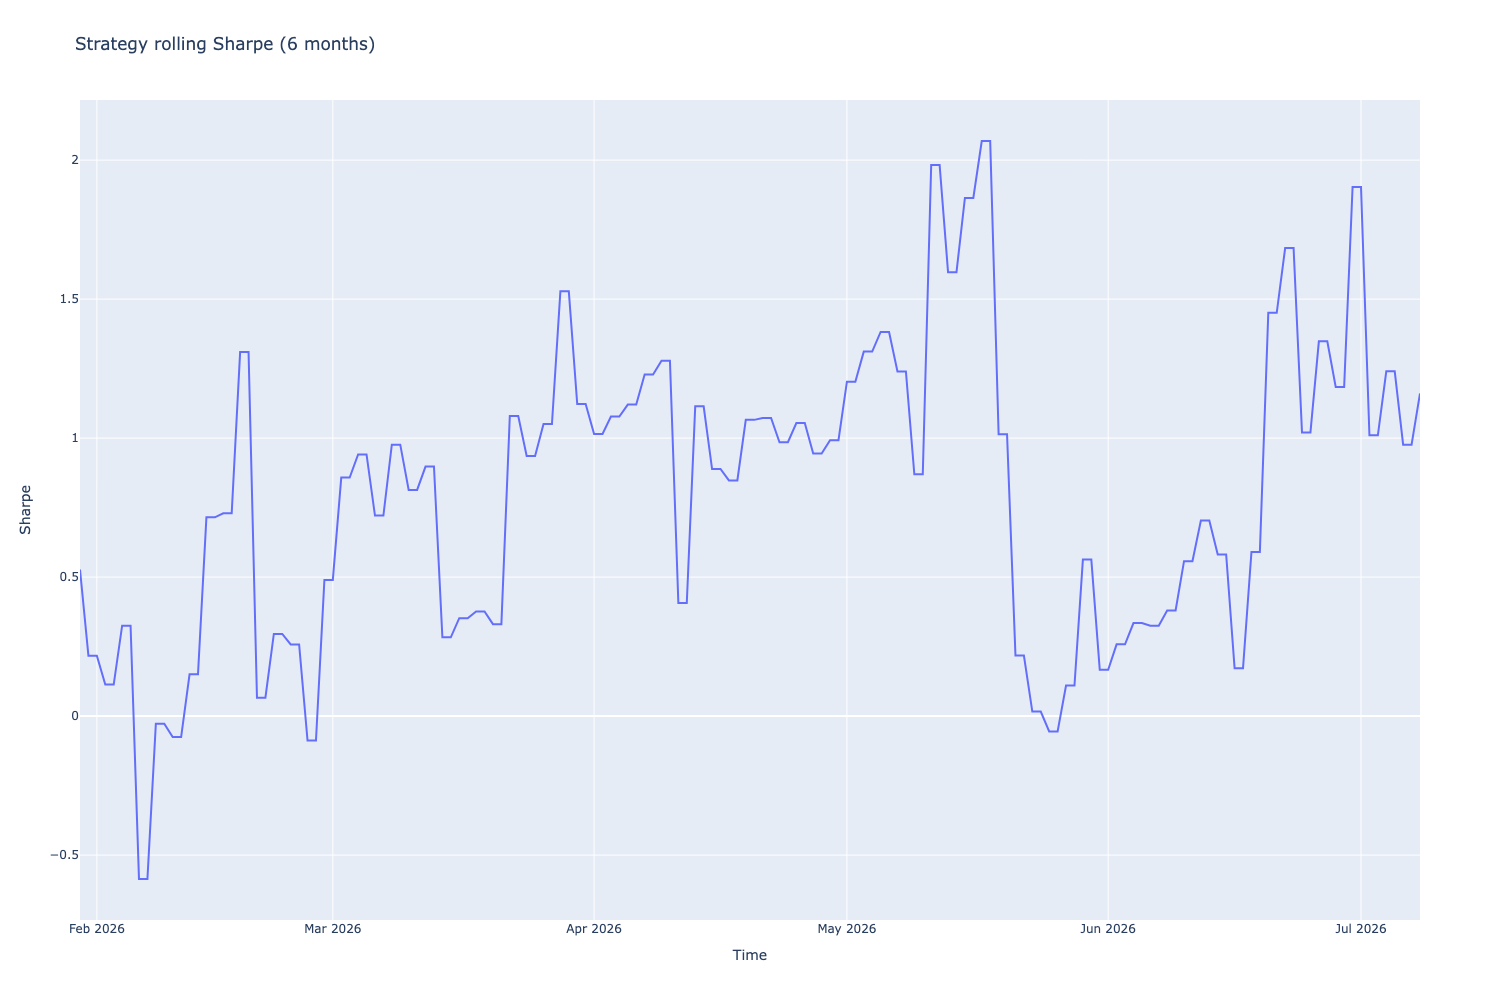

In [23]:
import plotly.express as px

from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns
from tradeexecutor.visual.equity_curve import calculate_rolling_sharpe

# A 180-day window over a ~190-day backtest leaves ~10 points; 30 days is readable.
rolling_sharpe = calculate_rolling_sharpe(
    returns,
    freq="D",
    periods=30,
)

fig = px.line(rolling_sharpe, title='Strategy rolling Sharpe (6 months)')
fig.update_layout(showlegend=False)
fig.update_yaxes(title="Sharpe")
fig.update_xaxes(title="Time")
fig.show()

# Data diagnosics

- Some example code to track down issues with data


In [24]:
# data = [{"Timestamp": s.calculated_at, "Equity": s.net_asset_value} for s in state.stats.portfolio]
# df = pd.DataFrame(data)
# df = df.set_index("Timestamp")

# with pd.option_context('display.min_rows', 50, "display.max_rows", 50):
#     display(df)

In [25]:
# for t in state.portfolio.get_all_trades():
#     if t.executed_at.date() == datetime.date(2023, 12, 29):
#         print(t, t.pair, t.get_value())

In [26]:
# import plotly.graph_objects as go

# pair_desc = (ChainId.ethereum, "uniswap-v3", "WBTC", "USDC", 0.0005)
# pair = strategy_universe.get_pair_by_human_description(pair_desc)
# df = strategy_universe.data_universe.candles.get_candles_by_pair(pair.internal_id)


# fig = go.Figure(data=go.Ohlc(x=df.timestamp,
#                     open=df.open,
#                     high=df.high,
#                     low=df.low,
#                     close=df.close))
# fig.show()

# with pd.option_context('display.min_rows', 5000, "display.max_rows", 5000, 'display.float_format', lambda x: f'{x:.6f}'):
#     display(df)